# Modelagem comparativa — Base 02: Metro Interstate Traffic Volume

**Base analisada:** Base 02 — tráfego de veículos por hora  
**Objetivo:** prever o volume de tráfego da próxima hora com SARIMAX, Holt-Winters,
Random Forest e SVR. A Decision Tree é um experimento adicional.
**Nome:** Guilherme Trindade de Souza

Como esta célula funciona — Preparação e configurações

Esta célula importa as bibliotecas, localiza a base e prepara as pastas de saída. Define previsão de uma hora, frequência horária, divisão cronológica 80/20 e semente 67.

Decisões: o treino começa na primeira hora e os modelos são reajustados a cada 168 horas, sem limitar o histórico a uma semana. O uso de uma thread reduz a concorrência de processamento, mas não garante baixo consumo de memória. Versões e SHA256 permitem identificar o ambiente e o arquivo utilizado.

In [1]:
from pathlib import Path
from time import perf_counter
import json
import hashlib
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import sklearn, statsmodels
from threadpoolctl import threadpool_limits
_blas_limit = threadpool_limits(limits=1)

BASE_ID = 'base_02'
TARGET = 'traffic_volume'
DATETIME_COL = 'date_time'
RANDOM_STATE = 67
HORIZON = 1
FREQ = 'h'
TRAIN_RATIO = 0.80
TRAIN_START_POS = 0     # todo o histórico disponível, desde a primeira hora
REFIT_HOURS = 168       # coeficientes reestimados semanalmente
VALIDATION_HOURS = 168
N_FOLDS = 2
OFFICIAL_MODELS = ['SARIMAX', 'Holt-Winters', 'Random Forest', 'SVR']
EXTRA_MODELS = ['Decision Tree']
STL_PERIODS = {'Diária': 24, 'Semanal': 168}
MODEL_NAMES = ['SVR', 'Decision Tree', 'Random Forest', 'SARIMAX', 'Holt-Winters']
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'data/raw/base_02').is_dir())
DATA_PATH = PROJECT_ROOT / 'data/raw/base_02/Metro_Interstate_Traffic_Volume_2016_2018_regularizada_sem_imputacao.csv'
RESULTS = PROJECT_ROOT / 'results'
for folder in ['metrics', 'predictions', 'residuals', 'feature_importance', 'tuning', 'analysis', 'figures/base_02']:
    (RESULTS / folder).mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.figsize': (13, 4), 'axes.grid': True, 'grid.alpha': .2})

def savefig(name):
    plt.tight_layout()
    plt.savefig(RESULTS / 'figures/base_02' / f'{name}.png', dpi=140, bbox_inches='tight')
    plt.show()

print('Versões:', platform.python_version(), pd.__version__, sklearn.__version__, statsmodels.__version__)
print('SHA256 entrada:', hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())

Versões: 3.12.5 2.2.2 1.6.1 0.14.6
SHA256 entrada: 3c105848c040bbbcf3deb07da26a5ab3a1487543c342dc0501ba97c63679bca4


## 1. Identificação da base e disponibilidade das variáveis

- **Fonte:** Metro Interstate Traffic Volume, disponibilizada pela UCI. A entrada
  deste trabalho é o CSV horário já regularizado fornecido pelo grupo.
- **Cobertura do recorte:** 01/01/2016 a 30/09/2018.
- **Frequência:** uma hora, com 24.096 posições na grade temporal.
- **Alvo:** `traffic_volume`, contagem de veículos na hora.
- **Horizonte:** uma hora. A previsão para `t` é emitida após observar `t-1`.
- **Ausentes:** horas sem medição continuam na grade; o alvo ausente não é inventado
  para calcular MAE, RMSE ou resíduos.

| Variável | Significado e unidade | Disponibilidade e uso |
|---|---|---|
| `traffic_volume` | veículos por hora | somente histórico anterior à previsão |
| `temp` | temperatura em kelvin | medição da hora anterior; transformação/escala no treino |
| `rain_1h` | chuva na hora, em milímetros | hora anterior; `log1p` nas features |
| `snow_1h` | neve na hora, em milímetros | hora anterior; `log1p` nas features |
| `clouds_all` | cobertura de nuvens, em porcentagem | hora anterior |
| `weather_main` | categoria meteorológica | hora anterior; codificação ajustada no treino |
| calendário | hora, dia da semana e época do ano | conhecido antecipadamente para a hora prevista |
| `traffic_volume_original` | cópia de controle do alvo | usada apenas na auditoria; excluída das features |

Clima observado na hora prevista ainda não está disponível na origem, por isso
entra defasado. O relógio local do CSV é preservado; nenhuma conversão de fuso é presumida.

## 2. Carregamento e auditoria temporal

Registrar a ordem original, esquema, duplicatas, ausentes e intervalos entre as
datas antes de ordenar. Como a entrada foi congelada com grade horária regular,
uma hora faltando ou repetida interrompe a execução e exige revisão da fonte.

Como esta célula funciona — Leitura e conferência da entrada

O CSV é lido com a coluna de datas convertida em timestamps. As verificações exigem colunas essenciais, datas válidas, horários únicos, intervalos de uma hora e volumes não negativos.

Decisão: inconsistências estruturais interrompem a execução em vez de serem corrigidas silenciosamente. Valores ausentes são permitidos; quando existe a coluna de controle, ela deve coincidir com o alvo.

In [2]:
raw = pd.read_csv(DATA_PATH, parse_dates=[DATETIME_COL])
required_columns = {DATETIME_COL, TARGET, 'temp', 'rain_1h', 'snow_1h',
                    'clouds_all', 'weather_main'}
assert required_columns <= set(raw.columns), f'Colunas ausentes: {required_columns - set(raw.columns)}'
assert raw[DATETIME_COL].notna().all(), 'Datas inválidas.'
assert not raw[DATETIME_COL].duplicated().any(), 'Timestamps duplicados.'
assert raw[TARGET].dropna().ge(0).all(), 'Volume negativo.'
ordered_dates = raw[DATETIME_COL].sort_values()
assert ordered_dates.diff().dropna().eq(pd.Timedelta(hours=1)).all(), 'Grade horária irregular.'
if 'traffic_volume_original' in raw:
    pd.testing.assert_series_equal(raw[TARGET], raw['traffic_volume_original'], check_names=False)

original_order = ('crescente' if raw[DATETIME_COL].is_monotonic_increasing else
                  'decrescente' if raw[DATETIME_COL].is_monotonic_decreasing else 'irregular')
audit = pd.DataFrame([{
    'observacoes': len(raw), 'inicio': ordered_dates.iloc[0], 'fim': ordered_dates.iloc[-1],
    'ordem_original': original_order, 'duplicatas': raw[DATETIME_COL].duplicated().sum(),
    'alvos_ausentes': raw[TARGET].isna().sum(),
    'nulos_totais': raw[list(required_columns)].isna().sum().sum(),
}])
display(audit, raw.head(3))

,observacoes,inicio,fim,ordem_original,duplicatas,alvos_ausentes,nulos_totais
0,24096,2016-01-01,2018-09-30 23:00:00,crescente,0,1012,6072


,date_time,temp,rain_1h,snow_1h,clouds_all,traffic_volume,holiday,weather_main,weather_description,timestamp_observado,timestamp_criado_na_regularizacao,traffic_volume_original,hora,dia_semana,mes,fim_de_semana
0,2016-01-01 00:00:00,265.94,0.0,0.0,90.0,1513.0,New Years Day,Haze,haze,True,False,1513.0,0,4,1,0
1,2016-01-01 01:00:00,266.00,0.0,0.0,90.0,1550.0,NaN,Snow,light snow,True,False,1550.0,1,4,1,0
2,2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,NaN,2,4,1,0


## 3. Limpeza e regularização horária

Ordenar explicitamente e conferir a grade de uma hora. O CSV já regularizado não
é reamostrado nem agregado novamente. Os alvos ausentes são preservados. No ajuste
tabular, linhas sem alvo são excluídas apenas do treino; Holt-Winters recebe uma
cópia causal preenchida com o último valor conhecido. A série real de avaliação
continua intacta em todos os modelos.

O limite de desenvolvimento é identificado aqui para restringir a exploração e
a STL ao passado. A divisão de treino, validação e teste é detalhada na etapa 7.

Como esta célula funciona — Organização da grade temporal

Os registros são ordenados, a data vira o índice e asfreq('h') estabelece a frequência. O alvo é separado em y e os primeiros 80% formam dev.

Decisão: como a entrada já está regularizada, não há nova agregação nem preenchimento do tráfego. As verificações confirmam que a quantidade de horas e de alvos ausentes foi preservada.

In [3]:
df = raw.sort_values(DATETIME_COL).set_index(DATETIME_COL).asfreq(FREQ)
assert len(df) == len(raw), 'A entrada deveria estar regularizada.'
assert df.index.is_monotonic_increasing and df.index.is_unique
assert df.index.to_series().diff().dropna().eq(pd.Timedelta(hours=1)).all()
assert df[TARGET].isna().sum() == raw[TARGET].isna().sum()
y = df[TARGET].astype(float)
split_pos = int(len(df) * TRAIN_RATIO)
dev = df.iloc[:split_pos]
print(f'{len(df):,} horas | {y.isna().sum():,} alvos ausentes | ordenação original: {original_order}')
display(df.head())

24,096 horas | 1,012 alvos ausentes | ordenação original: crescente


,temp,rain_1h,snow_1h,clouds_all,traffic_volume,holiday,weather_main,weather_description,timestamp_observado,timestamp_criado_na_regularizacao,traffic_volume_original,hora,dia_semana,mes,fim_de_semana
date_time,,,,,,,,,,,,,,,
2016-01-01 00:00:00,265.94,0.0,0.0,90.0,1513.0,New Years Day,Haze,haze,True,False,1513.0,0,4,1,0
2016-01-01 01:00:00,266.00,0.0,0.0,90.0,1550.0,NaN,Snow,light snow,True,False,1550.0,1,4,1,0
2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,NaN,2,4,1,0
2016-01-01 03:00:00,266.01,0.0,0.0,90.0,719.0,NaN,Snow,light snow,True,False,719.0,3,4,1,0
2016-01-01 04:00:00,264.80,0.0,0.0,90.0,533.0,NaN,Clouds,overcast clouds,True,False,533.0,4,4,1,0


## 4. Análise exploratória e valores atípicos

Explorar somente desenvolvimento. Picos de tráfego e clima são sinalizados por IQR,
sem exclusão automática: podem representar eventos reais ou problemas da fonte.
Nas features, valores meteorológicos negativos viram ausentes; chuva e neve usam
`log1p`. A auditoria e os gráficos mantêm os valores recebidos para permitir revisão.

Como esta célula funciona — Exploração sem usar o teste

A célula calcula estatísticas, correlações e extremos pelo IQR, além de desenhar tráfego, perfil por hora, temperatura e chuva no desenvolvimento.

Decisões: o teste fica fora desta exploração para não orientar escolhas com informação futura. Extremos são apenas sinalizados, não apagados. A temperatura é convertida para Celsius apenas no gráfico.

,count,mean,std,min,25%,50%,75%,max
traffic_volume,18279.0,3281.826249,1964.117979,0.00,1253.00,3460.00,4912.00,7280.00
temp,18279.0,280.710694,12.679525,243.39,271.75,281.69,291.21,307.33
rain_1h,18279.0,0.575328,72.718438,0.00,0.00,0.00,0.00,9831.30
snow_1h,18279.0,0.000071,0.003428,0.00,0.00,0.00,0.00,0.25
clouds_all,18279.0,43.368346,39.126645,0.00,1.00,40.00,90.00,100.00


,traffic_volume,temp,rain_1h,snow_1h,clouds_all
traffic_volume,1.000,0.124,0.008,-0.000,0.102
temp,0.124,1.000,0.013,-0.012,-0.032
rain_1h,0.008,0.013,1.000,-0.000,0.006
snow_1h,-0.000,-0.012,-0.000,1.000,0.024
clouds_all,0.102,-0.032,0.006,0.024,1.000


,variavel,atipicos_IQR,ausentes,tratamento
0,traffic_volume,0,997,preservados na auditoria
1,temp,0,997,preservados na auditoria
2,rain_1h,341,997,preservados na auditoria
3,snow_1h,10,997,preservados na auditoria
4,clouds_all,0,997,preservados na auditoria


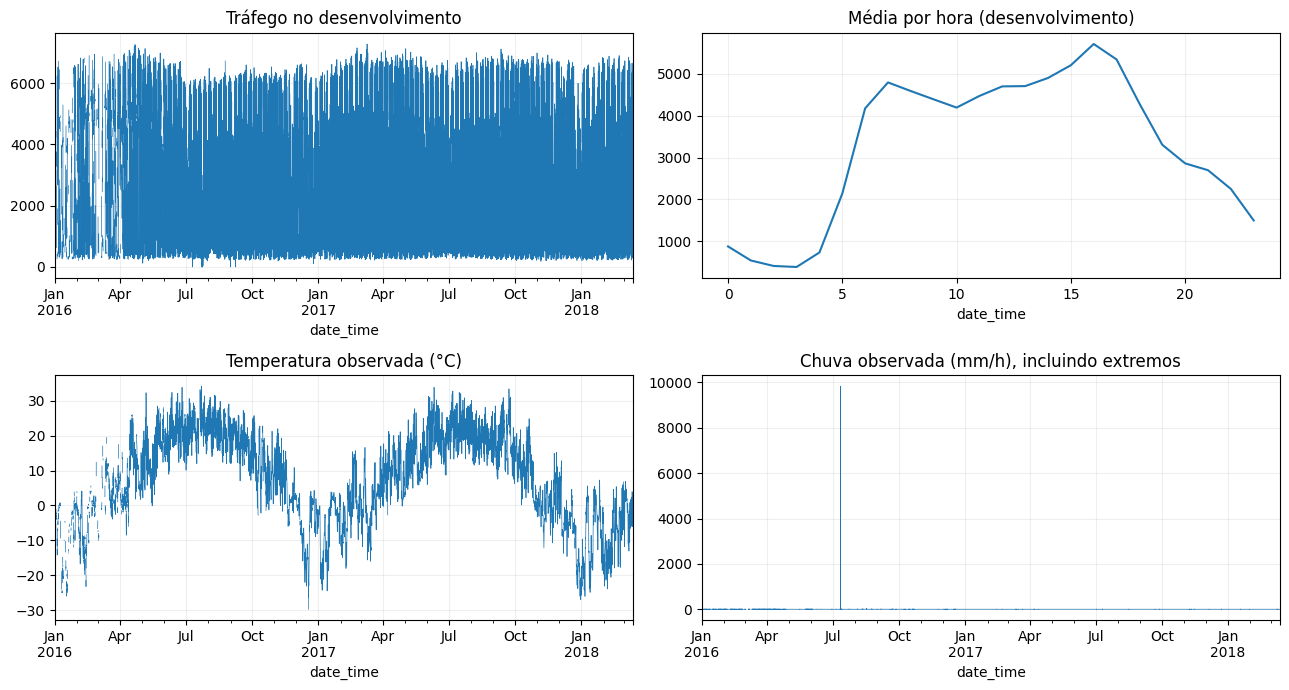

In [4]:
def iqr_outlier_mask(series):
    clean = series.dropna()
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

numeric_columns = [TARGET, 'temp', 'rain_1h', 'snow_1h', 'clouds_all']
outlier_summary = pd.DataFrame([
    {'variavel': col, 'atipicos_IQR': int(iqr_outlier_mask(dev[col]).sum()),
     'ausentes': int(dev[col].isna().sum()), 'tratamento': 'preservados na auditoria'}
    for col in numeric_columns
])
display(dev[numeric_columns].describe().T, dev[numeric_columns].corr().round(3), outlier_summary)


fig, axes = plt.subplots(2, 2, figsize=(13, 7))
dev[TARGET].plot(ax=axes[0,0], lw=.5, title='Tráfego no desenvolvimento')
dev.groupby(dev.index.hour)[TARGET].mean().plot(ax=axes[0,1], title='Média por hora (desenvolvimento)')
(dev['temp'] - 273.15).plot(ax=axes[1,0], lw=.5, title='Temperatura observada (°C)')
dev['rain_1h'].plot(ax=axes[1,1], lw=.5, title='Chuva observada (mm/h), incluindo extremos')
savefig('01_exploracao')

## 5. Decomposição STL e força da sazonalidade

Comparar periodicidades e discutir tendência, sazonalidade e
resíduos. Aqui os ciclos naturais são diário (24 horas) e semanal (168 horas).
A STL utiliza somente desenvolvimento, numa cópia descritiva com `ffill`.
Essa cópia não substitui o alvo real na avaliação. O período com maior força é
descritivo; os parâmetros dos modelos continuam escolhidos pela validação temporal.

Como esta célula funciona — Investigação dos ciclos

A STL robusta decompõe o desenvolvimento em tendência, sazonalidade e resíduos para períodos de 24 e 168 horas. A força sazonal mede quanto o componente periódico explica da variação restante.

Decisões: uma cópia é preenchida com o último valor conhecido para viabilizar a decomposição; o alvo original não muda. Robust=True reduz a influência de extremos. O ciclo mais forte é uma descrição, não uma escolha automática dos parâmetros dos modelos.

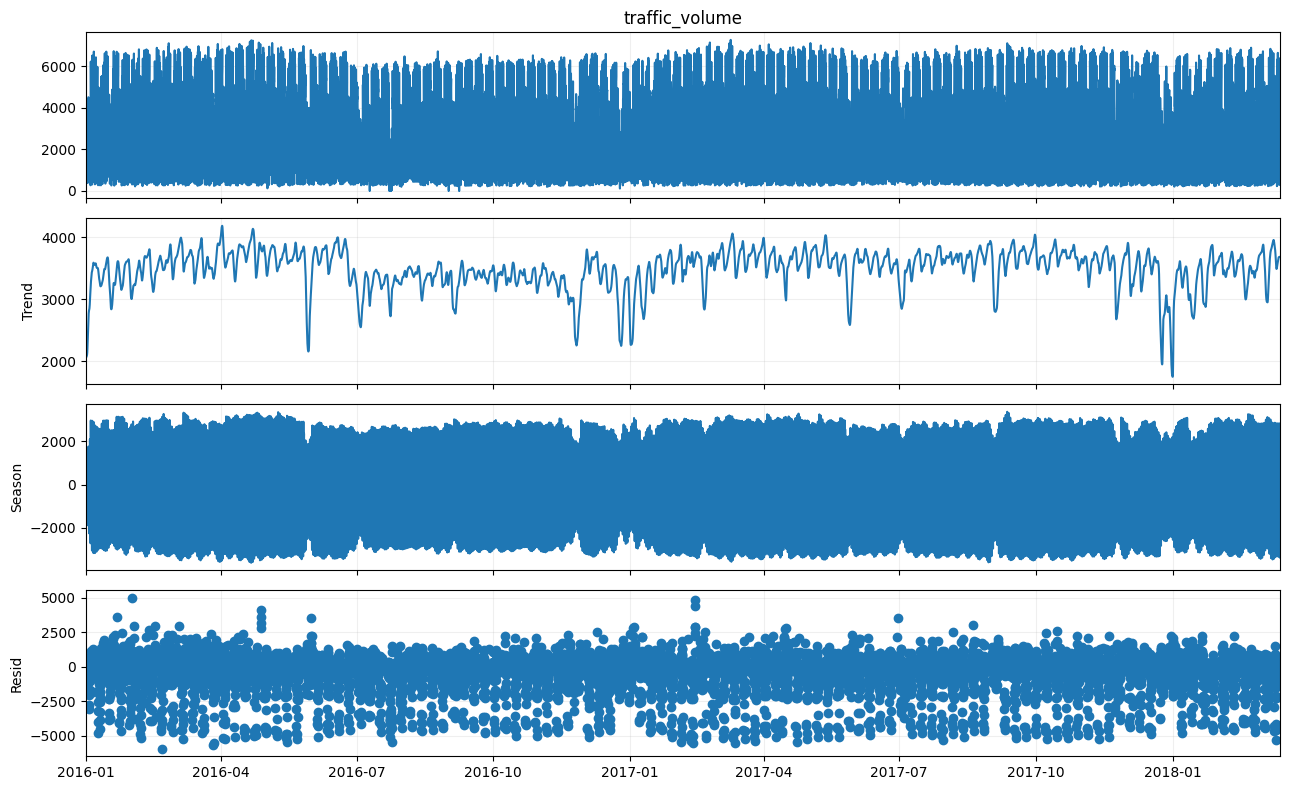

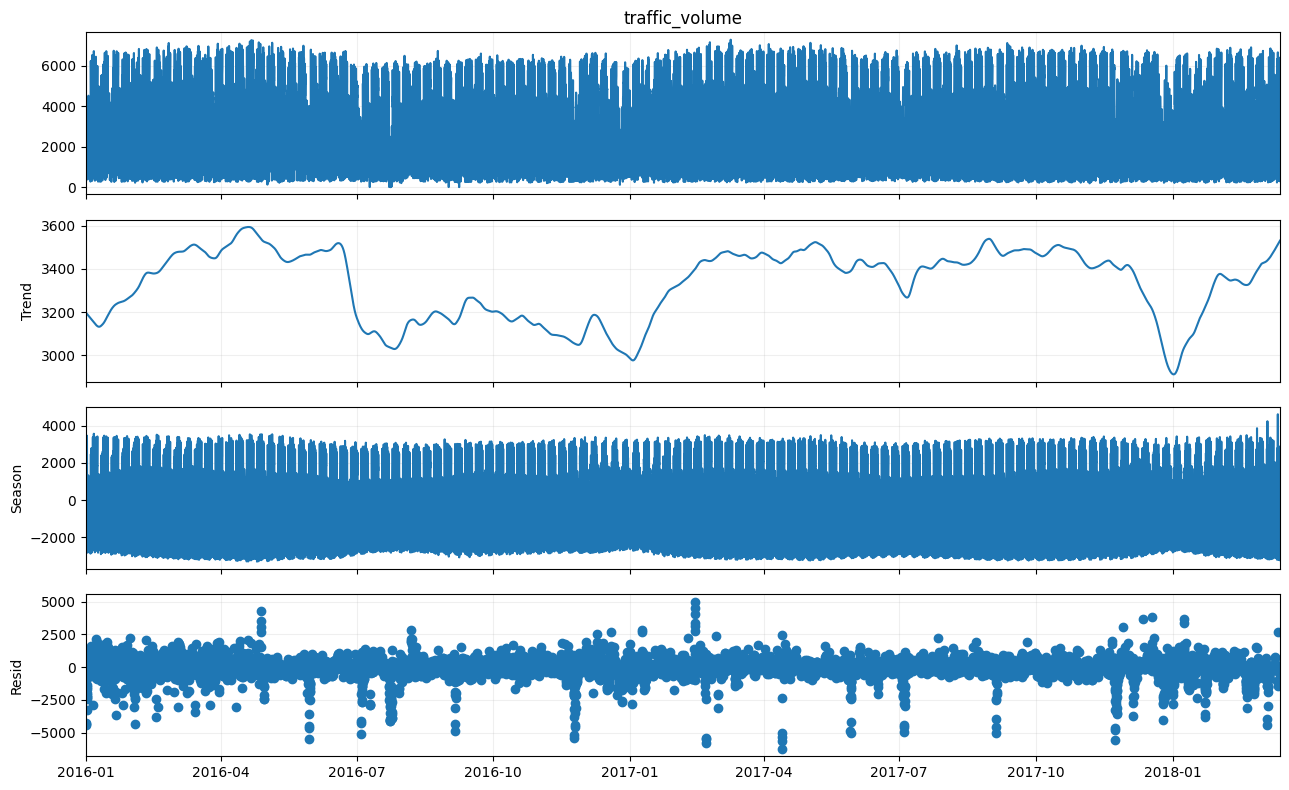

,periodicidade,periodo_horas,forca_sazonalidade
0,Diária,24,0.786814
1,Semanal,168,0.942337


Maior força no período de 168 h. Variação da tendência: 333.24 veículos/h. Desvio-padrão do resíduo: 470.93 veículos/h.


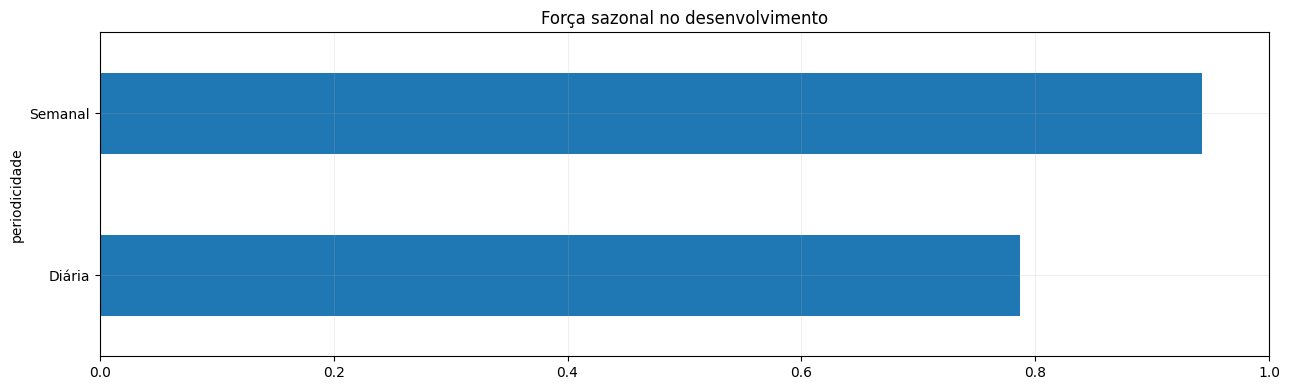

In [5]:
stl_rows, stl_results = [], {}
stl_series = y.iloc[:split_pos].ffill().dropna()
for period_name, period in STL_PERIODS.items():
    dec = STL(stl_series, period=period, robust=True).fit()
    denominator = np.var(dec.seasonal + dec.resid)
    strength = 0. if denominator == 0 else max(0., 1 - np.var(dec.resid) / denominator)
    stl_rows.append({'periodicidade': period_name, 'periodo_horas': period,
                     'forca_sazonalidade': strength})
    stl_results[period] = dec
    dec.plot()
    plt.gcf().set_size_inches(13, 8)
    savefig(f'02_stl_{period}')
stl_summary = pd.DataFrame(stl_rows)
display(stl_summary)
best_period = int(stl_summary.loc[stl_summary.forca_sazonalidade.idxmax(), 'periodo_horas'])
best_stl = stl_results[best_period]
print(f'Maior força no período de {best_period} h. '
      f'Variação da tendência: {best_stl.trend.iloc[-1] - best_stl.trend.iloc[0]:.2f} veículos/h. '
      f'Desvio-padrão do resíduo: {np.std(best_stl.resid):.2f} veículos/h.')
stl_summary.plot.barh(x='periodicidade', y='forca_sazonalidade', legend=False,
                     xlim=(0, 1), title='Força sazonal no desenvolvimento')
savefig('02_stl_forcas')

## 6. Feature engineering sem vazamento

Como esta célula funciona — Construção de informações do passado

make_features cria calendário, seno/cosseno dos ciclos, clima defasado, volumes de 1, 2, 3, 6, 12, 24, 48 e 168 horas atrás, estatísticas móveis e variações. Os indicadores de ausência distinguem falta de informação de um valor real.

Decisões: toda janela termina antes da hora prevista. O clima usa preenchimento causal limitado a seis horas, seguido de shift(1); chuva e neve recebem log1p para comprimir extremos. O calendário futuro é conhecido. Um teste altera presente e futuro e exige que as features até a hora da previsão permaneçam iguais, detectando vazamento.

In [6]:
def make_features(frame):
    t = frame.index
    X = pd.DataFrame(index=t)
    X['hora'] = t.hour
    X['dia_semana'] = t.dayofweek
    X['mes'] = t.month
    X['fim_de_semana'] = (t.dayofweek >= 5).astype(int)
    for name, values, cycle in [('hora', t.hour, 24), ('semana', t.dayofweek*24+t.hour, 168),
                                ('ano', t.dayofyear-1, 365.25)]:
        X[name+'_sin'] = np.sin(2*np.pi*values/cycle)
        X[name+'_cos'] = np.cos(2*np.pi*values/cycle)
    for col in ['temp','rain_1h','snow_1h','clouds_all']:
        s = frame[col].where(frame[col].ge(0)).ffill(limit=6).shift(1)
        X[col+'_lag1_ausente'] = s.isna().astype(int)
        X[col+'_lag1'] = np.log1p(s) if col in ['rain_1h','snow_1h'] else s
    X['weather_main_lag1'] = frame['weather_main'].ffill(limit=6).shift(1).fillna('Desconhecido')
    for lag in [1,2,3,6,12,24,48,168]:
        X[f'volume_lag{lag}'] = frame[TARGET].shift(lag)
        X[f'volume_lag{lag}_ausente'] = X[f'volume_lag{lag}'].isna().astype(int)
    past = frame[TARGET].shift(1)
    for window in [3,6,24,168]:
        roll = past.rolling(window, min_periods=max(2, window//4))
        X[f'media_{window}h'] = roll.mean()
        X[f'desvio_{window}h'] = roll.std()
        X[f'observacoes_{window}h'] = past.rolling(window, min_periods=1).count()
    X['variacao_1h'] = X.volume_lag1 - X.volume_lag2
    X['variacao_diaria'] = X.volume_lag1 - X.volume_lag24
    return X

X = make_features(df)
CAT_COLS = ['weather_main_lag1']
NUM_COLS = [c for c in X if c not in CAT_COLS]
EXOG_COLS = ['hora_sin','hora_cos','semana_sin','semana_cos','fim_de_semana',
             'temp_lag1','rain_1h_lag1','snow_1h_lag1','clouds_all_lag1']
assert TARGET not in X and 'traffic_volume_original' not in X
# Alterar presente e futuro não pode alterar features anteriores ou da própria origem.
probe = df.copy()
cut = split_pos - N_FOLDS * VALIDATION_HOURS
probe.loc[probe.index[cut]:, TARGET] = 999999.
probe.loc[probe.index[cut]:, ['temp','rain_1h','snow_1h','clouds_all']] = 999.
probe.loc[probe.index[cut]:, 'weather_main'] = 'FUTURO'
pd.testing.assert_frame_equal(X.iloc[:cut+1], make_features(probe).iloc[:cut+1])
print('Features:', X.shape[1], '| Teste de causalidade: passou')
display(X.iloc[168:173])
processed = pd.concat([y, X], axis=1)

Features: 49 | Teste de causalidade: passou


,hora,dia_semana,mes,fim_de_semana,hora_sin,hora_cos,semana_sin,semana_cos,ano_sin,ano_cos,...,desvio_6h,observacoes_6h,media_24h,desvio_24h,observacoes_24h,media_168h,desvio_168h,observacoes_168h,variacao_1h,variacao_diaria
date_time,,,,,,,,,,,,,,,,,,,,,
2016-01-08 00:00:00,0,4,1,0,0.000000,1.000000,-0.433884,-0.900969,0.120126,0.992759,...,1022.533292,3.0,3149.062500,2244.733792,16.0,2835.026087,1954.128811,115.0,NaN,683.0
2016-01-08 01:00:00,1,4,1,0,0.258819,0.965926,-0.467269,-0.884115,0.120126,0.992759,...,1223.471155,4.0,3153.437500,2239.409028,16.0,2827.330435,1961.110976,115.0,-613.0,305.0
2016-01-08 02:00:00,2,4,1,0,0.500000,0.866025,-0.500000,-0.866025,0.120126,0.992759,...,1144.797653,4.0,3155.687500,2236.391669,16.0,2816.973913,1971.035352,115.0,-269.0,44.0
2016-01-08 03:00:00,3,4,1,0,0.707107,0.707107,-0.532032,-0.846724,0.120126,0.992759,...,1144.797653,4.0,3345.066667,2178.043731,15.0,2816.973913,1971.035352,115.0,NaN,NaN
2016-01-08 04:00:00,4,4,1,0,0.866025,0.500000,-0.563320,-0.826239,0.120126,0.992759,...,406.709048,4.0,3336.866667,2189.624001,15.0,2814.208696,1974.224958,115.0,NaN,-680.0


## 7. Divisão temporal e protocolo walk-forward

Os primeiros 80% da grade horária são desenvolvimento e os últimos 20% são teste.
As duas semanas finais do desenvolvimento formam os folds de validação comuns.
Na previsão final, os hiperparâmetros ficam congelados; cada reajuste usa somente
todo o histórico desde a primeira hora até a origem e ocorre a cada 168 horas. Estados e histórico usados
pelas features são atualizados ao receber cada observação, após emitir a previsão.

Como esta célula funciona — Separação entre desenvolvimento, validação e teste

Esta célula apresenta os limites cronológicos dos conjuntos e constrói dois folds de validação de 168 horas no final do desenvolvimento. Cada fold tem treino começando na primeira hora e terminando antes da validação.

Decisões: não embaralhar preserva a ordem temporal. O percentual é calculado sobre a grade de horas, incluindo lacunas, e não apenas sobre medições disponíveis. A validação escolhe configurações; o teste final fica reservado para avaliá-las.

In [7]:
TEST_START = df.index[split_pos]
folds = [(split_pos - (N_FOLDS - k) * VALIDATION_HOURS,
          split_pos - (N_FOLDS - k - 1) * VALIDATION_HOURS) for k in range(N_FOLDS)]
assert TRAIN_START_POS == 0
assert folds[0][0] - TRAIN_START_POS >= 2 * max(STL_PERIODS.values())
display(pd.DataFrame([
    {'conjunto': 'Desenvolvimento', 'inicio': df.index[0], 'fim': df.index[split_pos-1],
     'horas': split_pos, 'alvos_observados': y.iloc[:split_pos].notna().sum()},
    {'conjunto': 'Teste final', 'inicio': TEST_START, 'fim': df.index[-1],
     'horas': len(df)-split_pos, 'alvos_observados': y.iloc[split_pos:].notna().sum()},
]))
display(pd.DataFrame([{'fold': i+1, 'treino_inicio': df.index[TRAIN_START_POS],
    'treino_fim': df.index[a-1], 'validacao_inicio': df.index[a], 'validacao_fim': df.index[b-1]}
    for i, (a,b) in enumerate(folds)]))
display(df[['temp','rain_1h','snow_1h','clouds_all',TARGET]].isna().sum().to_frame('ausentes'))
assert X.index.equals(y.index)
assert folds[-1][1] == split_pos

,conjunto,inicio,fim,horas,alvos_observados
0,Desenvolvimento,2016-01-01 00:00:00,2018-03-14 03:00:00,19276,18279
1,Teste final,2018-03-14 04:00:00,2018-09-30 23:00:00,4820,4805


,fold,treino_inicio,treino_fim,validacao_inicio,validacao_fim
0,1,2016-01-01,2018-02-28 03:00:00,2018-02-28 04:00:00,2018-03-07 03:00:00
1,2,2016-01-01,2018-03-07 03:00:00,2018-03-07 04:00:00,2018-03-14 03:00:00


,ausentes
temp,1012
rain_1h,1012
snow_1h,1012
clouds_all,1012
traffic_volume,1012


## 8. Seleção de hiperparâmetros somente no desenvolvimento

O critério de seleção dos hiperparâmetros é MAE nas duas semanas de
validação; nenhuma configuração é escolhida por desempenho no teste final.

- **SARIMAX:** três configurações de `p,d,q,P,D,Q`, com ciclo diário de 24 horas
  e exógenas disponíveis na origem. Registrar AIC, BIC, avisos e convergência.
- **Holt-Winters:** ciclo diário/semanal, tendência aditiva opcional e amortecimento.
  `alpha`, `beta` e `gamma` são explícitos nos candidatos; não são estimados automaticamente.
- **Random Forest:** número de árvores, profundidade, folhas, splits e proporção de features.
- **SVR:** `C`, `epsilon` e `gamma`, com kernel RBF e padronização das entradas no treino.
- **Decision Tree (extra):** profundidade, folhas e splits.

### 8.1 Construtores dos modelos tabulares e SARIMAX

Como esta célula funciona — Pré-processamento e construção dos modelos

Nos modelos tabulares, a Pipeline preenche números ausentes pela mediana, padroniza entradas e codifica o clima categórico. Linhas sem alvo são excluídas somente do ajuste. No SARIMAX, as exógenas recebem mediana e escala aprendidas no treino, além de uma constante explícita.

Decisões: o pré-processamento é reajustado dentro de cada treino para não usar estatísticas futuras. Categorias desconhecidas não interrompem a previsão. O SVR usa RBF e mantém o alvo em veículos/h; SARIMAX divide o alvo por mil e reconverte as previsões. extend filtra as observações em ordem, produzindo previsões de um passo antes de incorporar cada alvo. AIC, BIC e convergência são registrados.

In [8]:
def tabular_model(name, params):
    numeric = Pipeline([('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
                        ('scale', StandardScaler())])
    prep = ColumnTransformer([
        ('num', numeric, NUM_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)])
    if name == 'SVR':
        est = SVR(kernel='rbf', cache_size=512, **params)
    elif name == 'Decision Tree':
        est = DecisionTreeRegressor(random_state=RANDOM_STATE, **params)
    else:
        est = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1, **params)
    return Pipeline([('prep', prep), ('model', est)])

def forecast_tabular(name, params, ytr, Xtr, Xfuture):
    model = tabular_model(name, params)
    mask = ytr.notna()
    model.fit(Xtr.loc[mask], ytr.loc[mask])
    pred = model.predict(Xfuture)
    return pred, model, {}

def forecast_sarimax(params, ytr, yfuture, Xtr, Xfuture):
    prep = Pipeline([('fill', SimpleImputer(strategy='median', keep_empty_features=True)),
                     ('scale', StandardScaler())])
    ex_train = pd.DataFrame(prep.fit_transform(Xtr[EXOG_COLS]), index=ytr.index, columns=EXOG_COLS)
    ex_future = pd.DataFrame(prep.transform(Xfuture[EXOG_COLS]), index=yfuture.index, columns=EXOG_COLS)
    # Intercepto explícito evita conflito com exógenas constantes em blocos de uma hora.
    ex_train.insert(0, 'const', 1.)
    ex_future.insert(0, 'const', 1.)
    model = SARIMAX(ytr/1000., exog=ex_train, trend='n', **params,
                    enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False, maxiter=100)
    # extend filtra em ordem: fittedvalues[t] usa apenas observações até t-1.
    pred = np.asarray(fit.extend(yfuture/1000., exog=ex_future).fittedvalues)*1000.
    details = {'aic': fit.aic, 'bic': fit.bic,
               'convergiu': bool(fit.mle_retvals.get('converged', False))}
    return pred, (fit, prep, ex_future), details

### 8.2 Atualização causal de Holt-Winters e protocolo comum

Como esta célula funciona — Atualização horária e janela expansiva

hw_online emite a previsão de Holt-Winters antes de atualizar nível, tendência e sazonalidade com o valor observado. forecast_block entrega a cada modelo todo o prefixo anterior ao bloco e registra datas, tamanho do treino, duração e avisos.

Decisões: Holt-Winters usa preenchimento causal no treino e suavização aditiva com coeficientes explícitos, sem otimização automática. Nas horas futuras sem medição, a recursão avança sem tratar a previsão como observação real. Os cinco modelos devem produzir valores finitos; previsões negativas são limitadas a zero, pois contagens de veículos não podem ser negativas.

In [9]:
def hw_online(fit, values):
    """Recursão aditiva, equivalente às equações do statsmodels, com NaN causal."""
    p = fit.params
    alpha, gamma = p['smoothing_level'], p['smoothing_seasonal']
    has_trend = fit.model.has_trend
    beta = p['smoothing_trend'] if has_trend else 0.
    phi = p['damping_trend'] if fit.model.damped_trend else 1.
    level = float(fit.level.iloc[-1])
    trend = float(fit.trend.iloc[-1]) if has_trend else 0.
    season = np.asarray(fit.season[-fit.model.seasonal_periods:], dtype=float).copy()
    forecasts = []
    for i, actual in enumerate(values):
        j = i % len(season)
        base = level + phi*trend
        forecasts.append(base + season[j])  # emitir antes de observar actual
        if np.isfinite(actual):
            new_level = alpha*(actual-season[j]) + (1-alpha)*base
            new_trend = beta*(new_level-level) + (1-beta)*phi*trend if has_trend else 0.
            season[j] = gamma*(actual-base) + (1-gamma)*season[j]
            level, trend = new_level, new_trend
        else:
            level, trend = base, phi*trend
    return np.asarray(forecasts)

def forecast_holt_winters(params, start, first_train_hour, yfuture):
    # ffill causal sobre todo o prefixo; nenhum valor futuro preenche o treino.
    filled = y.iloc[:start].ffill().iloc[first_train_hour:start]
    assert filled.notna().all()
    trend = params['trend']
    model = ExponentialSmoothing(filled/1000., trend=trend, seasonal='add',
               seasonal_periods=params['seasonal_periods'],
               damped_trend=params['damped_trend'], initialization_method='heuristic')
    fit = model.fit(smoothing_level=params['alpha'],
                    smoothing_trend=params['beta'] if trend else None,
                    smoothing_seasonal=params['gamma'],
                    damping_trend=.98 if params['damped_trend'] else None,
                    optimized=False, remove_bias=False)
    pred = hw_online(fit, yfuture.to_numpy()/1000.)*1000.
    return pred, fit, {}

fit_logs = []
def forecast_block(name, params, start, stop, stage, return_artifact=False):
    a = TRAIN_START_POS
    assert 0 <= a < start < stop <= len(y)
    ytr, yfuture = y.iloc[a:start], y.iloc[start:stop]
    Xtr, Xfuture = X.iloc[a:start], X.iloc[start:stop]
    t0 = perf_counter()
    info = {'modelo': name, 'etapa': stage, 'treino_inicio': ytr.index[0],
            'treino_fim': ytr.index[-1], 'previsao_inicio': yfuture.index[0],
            'previsao_fim': yfuture.index[-1], 'n_treino_observado': int(ytr.notna().sum()),
            'n_treino_horas': len(ytr), 'janela_tipo': 'expansiva'}
    artifact = None
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        if name in ['SVR', 'Decision Tree', 'Random Forest']:
            pred, artifact, details = forecast_tabular(name, params, ytr, Xtr, Xfuture)
        elif name == 'SARIMAX':
            pred, artifact, details = forecast_sarimax(params, ytr, yfuture, Xtr, Xfuture)
        else:
            pred, artifact, details = forecast_holt_winters(params, start, a, yfuture)
        info.update(details)
        info['avisos'] = ' | '.join(sorted(set(str(w.message) for w in captured)))
    info['segundos'] = perf_counter()-t0
    fit_logs.append(info)
    assert len(pred) == stop-start and np.isfinite(pred).all(), f'Previsão inválida: {name}'
    # Volume físico não negativo: regra comum, definida antes da validação.
    pred = np.maximum(pred, 0.)
    return (pred, artifact) if return_artifact else pred

### 8.3 Grade de candidatos e seleção pelo MAE

Como esta célula funciona — Busca e escolha das configurações

A grade testa quatro candidatos de SVR, quatro de Decision Tree, três de Random Forest, três de SARIMAX e quatro de Holt-Winters. Cada candidato é avaliado nos dois folds e vence o menor MAE conjunto nas horas com alvo observado.

Decisões: a grade pequena viabiliza a execução local, mas não garante ótimo global. As duas semanas podem não representar todas as estações do ano. Falhas são registradas e descartadas; se todos os candidatos de um modelo falharem, a execução para. Os parâmetros vencedores são fixados antes do teste final.

In [10]:
GRIDS = {
    'SVR': [dict(C=c, epsilon=e, gamma=g) for c,e,g in
            [(100,.1,'scale'), (1000,50,'scale'), (5000,100,'scale'), (1000,50,.01)]],
    'Decision Tree': [dict(max_depth=d, min_samples_leaf=l, min_samples_split=s)
                      for d,l,s in [(6,5,10),(10,5,10),(14,10,20),(None,20,40)]],
    'Random Forest': [dict(n_estimators=n, max_depth=d, min_samples_leaf=l,
                          min_samples_split=s, max_features=f)
                      for n,d,l,s,f in [(80,12,2,4,.8),(120,None,4,8,.8),(120,16,6,12,1.)]],
    'SARIMAX': [dict(order=o, seasonal_order=s) for o,s in
                [((1,0,0),(1,0,0,24)), ((1,0,1),(1,0,0,24)), ((0,1,1),(0,1,0,24))]],
    'Holt-Winters': [dict(trend=t, damped_trend=d, seasonal_periods=m, alpha=a, beta=.02, gamma=g)
                     for t,d,m,a,g in [(None,False,24,.2,.1),('add',True,24,.4,.1),
                                       (None,False,168,.2,.1),('add',True,168,.4,.2)]]
}
display(pd.DataFrame([{'modelo': name, 'candidatos':len(grid), 'folds':N_FOLDS}
                     for name,grid in GRIDS.items()]))

search_rows = []
selected = {}
for name, grid in GRIDS.items():
    for candidate, params in enumerate(grid):
        errors = []
        row = {'modelo':name, 'candidato':candidate, 'parametros':json.dumps(params), 'status':'ok'}
        t0 = perf_counter()
        try:
            for k,(a,b) in enumerate(folds):
                pred = forecast_block(name, params, a,b, f'validacao_{candidate}_{k}')
                actual = y.iloc[a:b].to_numpy()
                mask = np.isfinite(actual)
                err = np.abs(actual[mask]-pred[mask])
                errors.extend(err)
                row[f'mae_fold_{k+1}'] = float(err.mean())
            row['mae_validacao'] = float(np.mean(errors))
        except Exception as exc:
            row.update(status='falhou', erro=repr(exc), mae_validacao=np.inf)
        row['segundos'] = perf_counter()-t0
        search_rows.append(row)
        print(name, candidate, row['status'], 'MAE:', round(row['mae_validacao'],2), flush=True)
    candidates = [r for r in search_rows if r['modelo']==name and r['status']=='ok']
    assert candidates, f'Todos os candidatos falharam: {name}'
    winner = min(candidates, key=lambda r:r['mae_validacao'])
    selected[name] = grid[winner['candidato']]
search = pd.DataFrame(search_rows)
search.to_csv(RESULTS/'tuning/base_02_search.csv', index=False)
display(search.sort_values(['modelo','mae_validacao']))
display(Markdown('**Configurações selecionadas antes do teste:**'))
display(pd.DataFrame([{'modelo':name, 'parametros':json.dumps(p)} for name,p in selected.items()]))

,modelo,candidatos,folds
0,SVR,4,2
1,Decision Tree,4,2
2,Random Forest,3,2
3,SARIMAX,3,2
4,Holt-Winters,4,2


SVR 0 ok MAE: 223.2
SVR 1 ok MAE: 171.75
SVR 2 ok MAE: 160.53
SVR 3 ok MAE: 187.22
Decision Tree 0 ok MAE: 305.95
Decision Tree 1 ok MAE: 243.6
Decision Tree 2 ok MAE: 228.05
Decision Tree 3 ok MAE: 251.91
Random Forest 0 ok MAE: 185.27
Random Forest 1 ok MAE: 177.15
Random Forest 2 ok MAE: 192.95
SARIMAX 0 ok MAE: 357.75
SARIMAX 1 ok MAE: 339.3
SARIMAX 2 ok MAE: 383.53
Holt-Winters 0 ok MAE: 558.94
Holt-Winters 1 ok MAE: 501.46
Holt-Winters 2 ok MAE: 225.89
Holt-Winters 3 ok MAE: 231.18


,modelo,candidato,parametros,status,mae_fold_1,mae_fold_2,mae_validacao,segundos
6,Decision Tree,2,"{""max_depth"": 14, ""min_samples_leaf"": 10, ""min...",ok,257.822681,197.927735,228.054534,1.634540
5,Decision Tree,1,"{""max_depth"": 10, ""min_samples_leaf"": 5, ""min_...",ok,270.351539,216.533696,243.603749,1.330923
7,Decision Tree,3,"{""max_depth"": null, ""min_samples_leaf"": 20, ""m...",ok,264.793708,238.872678,251.910801,1.585413
4,Decision Tree,0,"{""max_depth"": 6, ""min_samples_leaf"": 5, ""min_s...",ok,321.248470,290.468965,305.950872,1.044114
16,Holt-Winters,2,"{""trend"": null, ""damped_trend"": false, ""season...",ok,222.184598,229.650066,225.894980,0.087198
17,Holt-Winters,3,"{""trend"": ""add"", ""damped_trend"": true, ""season...",ok,211.497321,251.105365,231.182756,0.344454
15,Holt-Winters,1,"{""trend"": ""add"", ""damped_trend"": true, ""season...",ok,480.900856,522.266950,501.460052,0.408458
14,Holt-Winters,0,"{""trend"": null, ""damped_trend"": false, ""season...",ok,548.810339,569.199628,558.943938,0.098285
9,Random Forest,1,"{""n_estimators"": 120, ""max_depth"": null, ""min_...",ok,189.142979,165.010087,177.148787,107.555680
8,Random Forest,0,"{""n_estimators"": 80, ""max_depth"": 12, ""min_sam...",ok,206.141882,164.138533,185.265966,52.193664


**Configurações selecionadas antes do teste:**

,modelo,parametros
0,SVR,"{""C"": 5000, ""epsilon"": 100, ""gamma"": ""scale""}"
1,Decision Tree,"{""max_depth"": 14, ""min_samples_leaf"": 10, ""min..."
2,Random Forest,"{""n_estimators"": 120, ""max_depth"": null, ""min_..."
3,SARIMAX,"{""order"": [1, 0, 1], ""seasonal_order"": [1, 0, ..."
4,Holt-Winters,"{""trend"": null, ""damped_trend"": false, ""season..."


### 8.4 Verificação das previsões sequenciais

Antes do teste, conferir SARIMAX em lote contra previsão/atualização hora a hora,
e a recursão de Holt-Winters contra statsmodels com os mesmos parâmetros.

Como esta célula funciona — Conferência das recursões

Em 24 horas de validação, compara as previsões filtradas em lote do SARIMAX com forecast seguido de extend hora a hora. Também compara a recursão de Holt-Winters com statsmodels sob os mesmos parâmetros.

Decisão: estas verificações ajudam a confirmar que implementar um bloco não transformou a previsão de uma hora em uma previsão de várias horas sem atualização. Alterar o primeiro alvo futuro não pode mudar a primeira previsão de Holt-Winters; tolerâncias numéricas acomodam arredondamentos.

In [11]:
a,b = folds[-1]
batch, artifact = forecast_block('SARIMAX', selected['SARIMAX'], a,a+24,'verificacao',True)
fit, prep, ex = artifact
sequential = []
for j in range(24):
    sequential.append(float(fit.forecast(1, exog=ex.iloc[j:j+1]).iloc[0])*1000.)
    fit = fit.extend(y.iloc[a+j:a+j+1]/1000., exog=ex.iloc[j:j+1])
np.testing.assert_allclose(batch, np.maximum(sequential,0), rtol=1e-5, atol=1e-4)

_, hw = forecast_block('Holt-Winters', selected['Holt-Winters'], a,a+24,'verificacao',True)
p = hw.params
observed = y.iloc[a:a+24].ffill().fillna(y.iloc[a-1])/1000.
combined = pd.concat([pd.Series(hw.model.endog, index=hw.model._index), observed])
equivalent = ExponentialSmoothing(combined, trend=hw.model.trend, seasonal='add',
    seasonal_periods=hw.model.seasonal_periods, damped_trend=hw.model.damped_trend,
    initialization_method='known', initial_level=p['initial_level'],
    initial_trend=p['initial_trend'] if hw.model.has_trend else None,
    initial_seasonal=p['initial_seasons']).fit(
    smoothing_level=p['smoothing_level'], smoothing_trend=p['smoothing_trend'] if hw.model.has_trend else None,
    smoothing_seasonal=p['smoothing_seasonal'],
    damping_trend=p['damping_trend'] if hw.model.damped_trend else None, optimized=False)
np.testing.assert_allclose(hw_online(hw, observed), equivalent.fittedvalues.iloc[-24:], rtol=1e-6, atol=1e-7)
# O primeiro forecast independe do primeiro alvo futuro, inclusive se ele mudar muito.
changed = observed.to_numpy().copy(); changed[0] += 10000
assert hw_online(hw, changed)[0] == hw_online(hw, observed)[0]
print('SARIMAX: lote = sequencial. Holt-Winters: recursão = statsmodels. Verificações passaram.')

SARIMAX: lote = sequencial. Holt-Winters: recursão = statsmodels. Verificações passaram.


## 9. Previsões do SARIMAX com variáveis externas

O modelo recebe exógenas conhecidas na origem e atualiza seu estado
depois de cada observação. O ajuste de cada semana usa todo o histórico anterior à origem;
imputação e escala são ajustadas nesse treino. A constante é incluída explicitamente.
Os coeficientes ficam fixos dentro da semana e são reestimados no próximo bloco.

Como esta célula funciona — Execução do SARIMAX no teste

walk_forward_test divide o teste em blocos de até 168 horas. No início de cada bloco, o modelo é ajustado com todo o histórico anterior; em seguida, são obtidas previsões horárias e registrados origem, data prevista, valor real, previsão e resíduo.

Decisões: a janela cresce e incorpora observações já recebidas do teste, sem reescolher hiperparâmetros. Isso simula operação com atualização, não uma previsão de todos os meses feita em uma única data. O progresso é impresso a cada oito blocos; intervalos sem mensagem podem conter processamento. Esta célula chama o protocolo para SARIMAX e mede seu tempo.

In [12]:
prediction_rows, runtime = [], {}

def walk_forward_test(name):
    """Aplica o protocolo comum com os hiperparâmetros já selecionados."""
    started = perf_counter()
    values = []
    for block, start in enumerate(range(split_pos, len(df), REFIT_HOURS)):
        stop = min(start + REFIT_HOURS, len(df))
        values.extend(forecast_block(name, selected[name], start, stop, 'teste'))
        if block % 8 == 0:
            print(name, 'semana', block + 1, 'até', df.index[stop - 1], flush=True)
    elapsed = perf_counter() - started
    result = pd.DataFrame({
        'base': BASE_ID, 'modelo': name,
        'data_origem': df.index[split_pos:] - pd.Timedelta(hours=1),
        'data_prevista': df.index[split_pos:], 'horizonte': HORIZON,
        'valor_real': y.iloc[split_pos:].to_numpy(), 'valor_previsto': values,
    })
    result['residuo'] = result.valor_real - result.valor_previsto
    result['alvo_observado'] = result.valor_real.notna()
    print('Parâmetros:', selected[name], '| segundos:', round(elapsed, 1))
    return result, elapsed

result, runtime['SARIMAX'] = walk_forward_test('SARIMAX')
prediction_rows.append(result)

SARIMAX semana 1 até 2018-03-21 03:00:00
SARIMAX semana 9 até 2018-05-16 03:00:00
SARIMAX semana 17 até 2018-07-11 03:00:00
SARIMAX semana 25 até 2018-09-05 03:00:00
Parâmetros: {'order': (1, 0, 1), 'seasonal_order': (1, 0, 0, 24)} | segundos: 3615.7


## 10. Previsões do Holt-Winters

Referência univariada, sem clima ou calendário como entradas externas. A cópia de
treino é preenchida causalmente por `ffill`. A recursão emite a previsão antes de
incorporar o valor da hora e preserva horas sem alvo. Os estados evoluem a cada hora;
o ajuste semanal mantém os parâmetros selecionados na validação.

Como esta célula funciona — Execução do Holt-Winters no teste

Aplica ao Holt-Winters o mesmo intervalo de teste e reajuste semanal, acrescentando suas previsões à lista comum e guardando o tempo de execução.

Decisão: usar o mesmo protocolo torna a comparação mais consistente. A diferença está nas entradas: Holt-Winters utiliza apenas o histórico do tráfego e seus componentes, sem clima externo.

In [13]:
result, runtime['Holt-Winters'] = walk_forward_test('Holt-Winters')
prediction_rows.append(result)

Holt-Winters semana 1 até 2018-03-21 03:00:00
Holt-Winters semana 9 até 2018-05-16 03:00:00
Holt-Winters semana 17 até 2018-07-11 03:00:00
Holt-Winters semana 25 até 2018-09-05 03:00:00
Parâmetros: {'trend': None, 'damped_trend': False, 'seasonal_periods': 168, 'alpha': 0.2, 'beta': 0.02, 'gamma': 0.1} | segundos: 1.3


## 11. Walk-forward do Random Forest

Usar as mesmas features e datas que os demais modelos. A cada reajuste semanal,
reconstruir a floresta e o pré-processamento usando apenas o histórico permitido.
Os hiperparâmetros escolhidos e o `random_state=67` ficam fixos.

Como esta célula funciona — Execução do Random Forest no teste

Aplica o walk-forward à floresta com a configuração selecionada. Em cada reajuste, reconstrói o modelo e o pré-processamento sobre todo o histórico permitido.

Decisões: a semente 67 favorece a reprodução dos ajustes, e n_jobs=1 evita paralelizar árvores. Dentro do bloco, as features de cada hora usam observações anteriores já disponíveis, mas a floresta só é reajustada no próximo bloco.

In [14]:
result, runtime['Random Forest'] = walk_forward_test('Random Forest')
prediction_rows.append(result)

Random Forest semana 1 até 2018-03-21 03:00:00
Random Forest semana 9 até 2018-05-16 03:00:00
Random Forest semana 17 até 2018-07-11 03:00:00
Random Forest semana 25 até 2018-09-05 03:00:00
Parâmetros: {'n_estimators': 120, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 8, 'max_features': 0.8} | segundos: 1766.9


### 11.1 Decision Tree — experimento adicional

Como esta célula funciona — Experimento com uma árvore individual

Executa a Decision Tree nas mesmas datas, features e condições da Random Forest e guarda previsões e duração.

Decisão: a árvore permite comparar um modelo individual com um conjunto de árvores. Seu resultado é apresentado como experimento adicional e não entra no ranking oficial dos quatro modelos.

In [15]:
result, runtime['Decision Tree'] = walk_forward_test('Decision Tree')
prediction_rows.append(result)

Decision Tree semana 1 até 2018-03-21 03:00:00
Decision Tree semana 9 até 2018-05-16 03:00:00
Decision Tree semana 17 até 2018-07-11 03:00:00
Decision Tree semana 25 até 2018-09-05 03:00:00
Parâmetros: {'max_depth': 14, 'min_samples_leaf': 10, 'min_samples_split': 20} | segundos: 26.8


## 12. SVR: estudo do modelo de especialização e previsões

O SVR ajusta uma função tolerando erros dentro de um tubo definido por `epsilon`.
O kernel RBF representa relações não lineares entre histórico do tráfego, clima
defasado e calendário da hora prevista.

- **Preparação:** medianas, padronização numérica e categorias são aprendidas em
  cada treino. O alvo continua em veículos/h.
- **`C`:** penaliza erros fora do tubo; valores maiores favorecem ajuste mais rígido.
- **`epsilon`:** tolerância em veículos/h; valores maiores reduzem a sensibilidade
  a pequenas diferenças entre tráfego real e previsto.
- **`gamma`:** alcance do kernel; valores maiores tornam as relações mais locais.
- **Vantagens:** flexibilidade não linear e solução convexa com hiperparâmetros fixos.
- **Limitações:** custo de ajuste, sensibilidade à escala e ausência de importância nativa.
- **Otimização e interpretação:** MAE nas duas semanas de validação e permutation
  importance na última semana de validação, com modelo treinado anteriormente.

Como esta célula funciona — Execução do SVR e conferência das previsões

Executa o SVR, reúne as previsões dos cinco modelos e verifica igualdade de cobertura, ausência de duplicatas, previsões preenchidas e diferença exata de uma hora entre origem e data prevista.

Decisão: antes de comparar erros, todos devem prever as mesmas datas e ter a mesma quantidade de alvos observados. As features do teste incorporam somente informações anteriores a cada previsão, enquanto o ajuste do SVR ocorre semanalmente.

In [16]:
result, runtime['SVR'] = walk_forward_test('SVR')
prediction_rows.append(result)

predictions = pd.concat(prediction_rows,ignore_index=True)
counts = predictions.groupby('modelo').agg(horas=('data_prevista','size'), avaliadas=('alvo_observado','sum'))
assert counts.horas.nunique()==1 and counts.avaliadas.nunique()==1
assert not predictions.duplicated(['modelo','data_prevista']).any()
assert predictions.valor_previsto.notna().all()
assert ((predictions.data_prevista-predictions.data_origem)==pd.Timedelta(hours=1)).all()

display(counts)

SVR semana 1 até 2018-03-21 03:00:00
SVR semana 9 até 2018-05-16 03:00:00
SVR semana 17 até 2018-07-11 03:00:00
SVR semana 25 até 2018-09-05 03:00:00
Parâmetros: {'C': 5000, 'epsilon': 100, 'gamma': 'scale'} | segundos: 1838.9


,horas,avaliadas
modelo,,
Decision Tree,4820,4805
Holt-Winters,4820,4805
Random Forest,4820,4805
SARIMAX,4820,4805
SVR,4820,4805


## 13. Comparação por MAE e análise dos resultados

Avaliar todos os modelos nas mesmas horas com alvo realmente observado. MAE é a
métrica principal, em veículos/h; RMSE destaca erros grandes e viés positivo
(`real - previsto`) indica subestimação. Tempos incluem ajuste e previsão do teste.
O ranking oficial contém somente SARIMAX, Holt-Winters, Random Forest e SVR; a
Decision Tree aparece separadamente. MAEs de bases com unidades diferentes não
devem ser somados nem comparados diretamente.

Como esta célula funciona — Métricas e ranking

Calcula MAE, RMSE, viés médio e tempo de teste para cada modelo, excluindo horas sem alvo real. Mostra o MAE da validação e separa ranking oficial de experimento adicional.

Decisões: MAE é a métrica principal por ser interpretável em veículos/h; RMSE destaca erros grandes. Como o resíduo é real menos previsto, viés positivo indica subestimação. O tempo inclui ajustes e previsões do teste, não toda a busca de parâmetros. Os gráficos comparam erro e custo dos quatro modelos oficiais.

Ranking oficial — quatro modelos exigidos


,ranking_oficial,modelo,mae,rmse,vies,n_avaliadas,tempo_teste_s,mae_validacao
0,1,Random Forest,134.742,214.027,-9.669,4805,1766.877,177.149
1,2,SVR,143.514,223.656,-0.650,4805,1838.856,160.527
3,3,Holt-Winters,199.137,317.280,-2.327,4805,1.295,225.895
4,4,SARIMAX,290.411,418.085,1.479,4805,3615.740,339.295


Experimento adicional


,base,modelo,mae,rmse,vies,n_previsoes,n_avaliadas,tempo_teste_s,mae_validacao,ranking,escopo,ranking_oficial
2,base_02,Decision Tree,173.149,275.413,-8.597,4820,4805,26.828,228.055,3,extra,<NA>


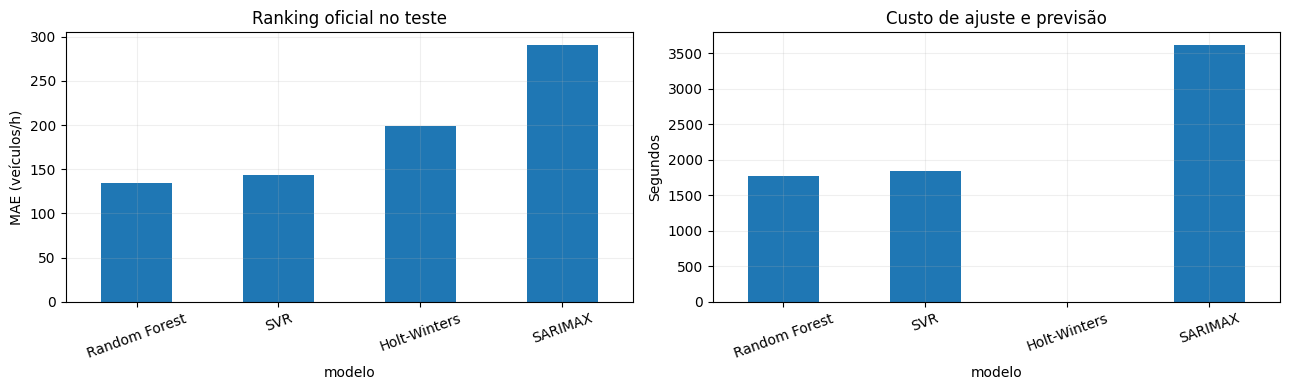

In [17]:
metric_rows = []
for name, group in predictions.groupby('modelo', sort=False):
    valid = group.dropna(subset=['valor_real'])
    metric_rows.append({'base':BASE_ID, 'modelo':name, 'mae':mean_absolute_error(valid.valor_real,valid.valor_previsto),
        'rmse':np.sqrt(mean_squared_error(valid.valor_real,valid.valor_previsto)),
        'vies':valid.residuo.mean(), 'n_previsoes':len(group), 'n_avaliadas':len(valid),
        'tempo_teste_s':runtime[name],
        'mae_validacao':search.loc[search.modelo.eq(name),'mae_validacao'].min()})
metrics = pd.DataFrame(metric_rows).sort_values('mae').reset_index(drop=True)
metrics['ranking'] = metrics.mae.rank(method='min').astype(int)


official_mask = metrics.modelo.isin(OFFICIAL_MODELS)
metrics['escopo'] = np.where(official_mask, 'oficial', 'extra')
metrics['ranking_oficial'] = pd.Series(pd.NA, index=metrics.index, dtype='Int64')
metrics.loc[official_mask, 'ranking_oficial'] = metrics.loc[official_mask, 'mae'].rank(method='min').astype('Int64')
official_metrics = metrics.loc[official_mask].copy()
print('Ranking oficial — quatro modelos exigidos')
display(official_metrics[['ranking_oficial', 'modelo', 'mae', 'rmse', 'vies',
                          'n_avaliadas', 'tempo_teste_s', 'mae_validacao']].round(3))
print('Experimento adicional')
display(metrics.loc[~official_mask].round(3))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
official_metrics.plot.bar(x='modelo', y='mae', ax=axes[0], legend=False, rot=20)
axes[0].set_ylabel('MAE (veículos/h)'); axes[0].set_title('Ranking oficial no teste')
official_metrics.plot.bar(x='modelo', y='tempo_teste_s', ax=axes[1], legend=False, rot=20)
axes[1].set_ylabel('Segundos'); axes[1].set_title('Custo de ajuste e previsão')
savefig('03_comparacao')

Como esta célula funciona — Estabilidade dos erros e referência simples

O gráfico de previsões mostra somente a primeira semana para facilitar a leitura, mas os erros por hora do dia e por mês usam todo o teste observado. O benchmark semanal prevê repetindo o volume de 168 horas atrás.

Decisão: o benchmark é comparado aos modelos apenas no subconjunto em que tanto o alvo atual quanto o valor semanal anterior existem. Essa comparação tem cobertura própria e não deve ser confundida automaticamente com o MAE global.

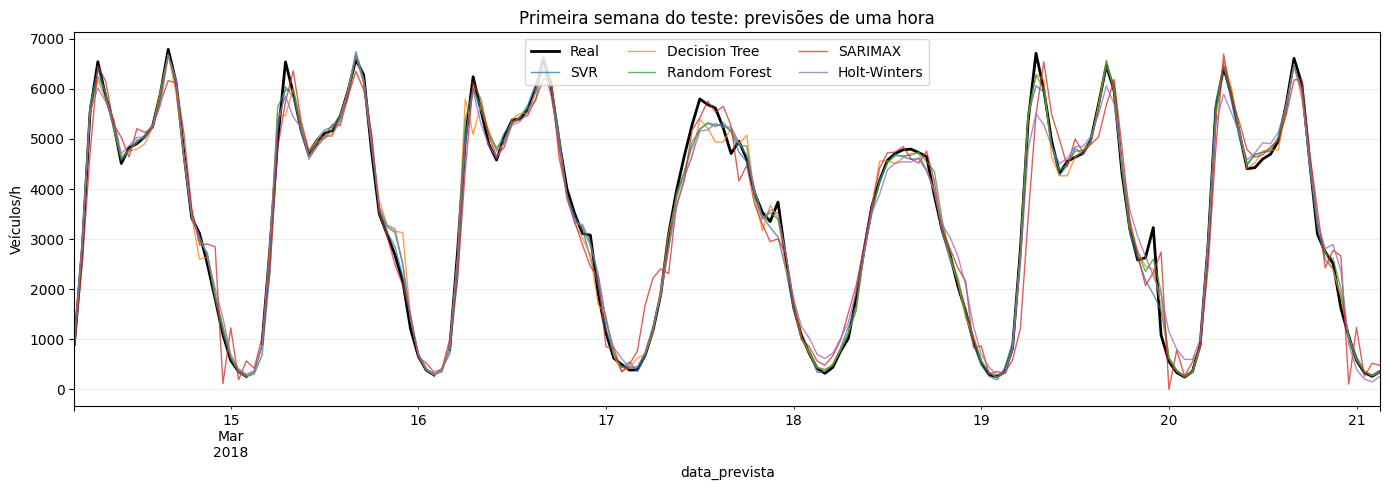

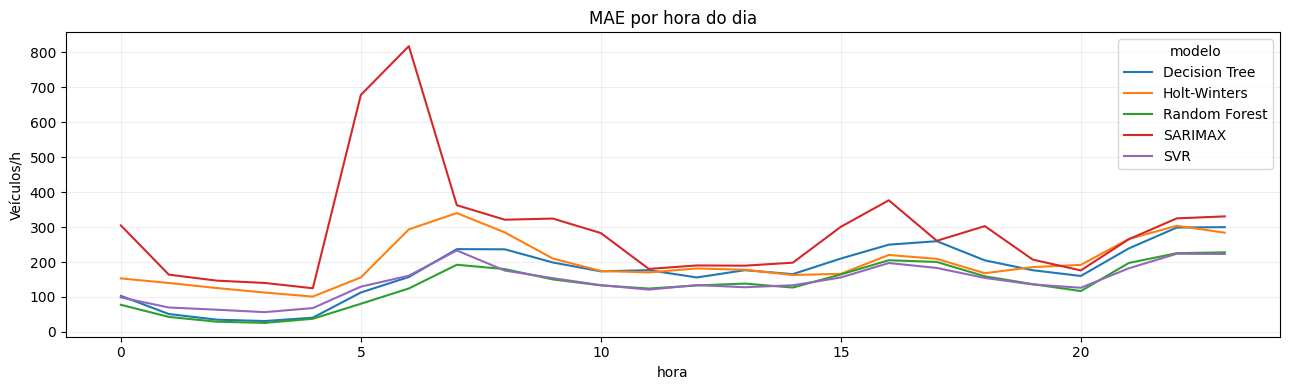

modelo,Decision Tree,Holt-Winters,Random Forest,SARIMAX,SVR
mes_teste,,,,,
2018-03,200.88,215.27,154.18,331.56,164.26
2018-04,218.55,250.61,177.11,312.54,176.68
2018-05,169.85,210.13,135.05,296.05,145.77
2018-06,153.66,154.59,116.32,270.25,120.64
2018-07,169.38,196.26,123.22,280.57,130.28
2018-08,146.61,153.03,110.72,262.29,131.47
2018-09,165.66,221.78,135.74,297.74,144.83


**Benchmark: comparação no subconjunto comum com lag de 168 h observado.**

,modelo,mae_mesmas_datas,n
3,Random Forest,134.86,4788
1,SVR,143.47,4788
2,Decision Tree,172.92,4788
5,Holt-Winters,199.41,4788
4,SARIMAX,290.49,4788
0,Sazonal ingênuo (168 h),293.65,4788


In [18]:
wide = predictions.pivot(index='data_prevista',columns='modelo',values='valor_previsto')
fig,ax = plt.subplots(figsize=(14,5))
y.loc[wide.index].iloc[:168].plot(ax=ax,color='black',lw=2,label='Real')
for name in MODEL_NAMES:
    wide[name].iloc[:168].plot(ax=ax,alpha=.75,lw=1,label=name)
ax.set_title('Primeira semana do teste: previsões de uma hora'); ax.set_ylabel('Veículos/h'); ax.legend(ncol=3)
savefig('04_previsoes')

valid_errors = predictions[predictions.alvo_observado].copy()
valid_errors['erro_absoluto'] = valid_errors.residuo.abs()
valid_errors['hora'] = valid_errors.data_prevista.dt.hour
valid_errors['mes_teste'] = valid_errors.data_prevista.dt.to_period('M').astype(str)
hourly = valid_errors.pivot_table(index='hora',columns='modelo',values='erro_absoluto',aggfunc='mean')
monthly = valid_errors.pivot_table(index='mes_teste',columns='modelo',values='erro_absoluto',aggfunc='mean')
hourly.plot(title='MAE por hora do dia', ylabel='Veículos/h'); savefig('05_mae_hora')
display(monthly.round(2))
naive = y.shift(168).loc[wide.index]
mask = y.loc[wide.index].notna() & naive.notna()
baseline_rows = [{'modelo':'Sazonal ingênuo (168 h)', 'mae_mesmas_datas':mean_absolute_error(y.loc[wide.index][mask],naive[mask]),'n':int(mask.sum())}]
baseline_rows += [{'modelo':name,'mae_mesmas_datas':mean_absolute_error(y.loc[wide.index][mask],wide.loc[mask,name]),'n':int(mask.sum())} for name in MODEL_NAMES]
baseline_comparison = pd.DataFrame(baseline_rows).sort_values('mae_mesmas_datas')
display(Markdown('**Benchmark: comparação no subconjunto comum com lag de 168 h observado.**'))
display(baseline_comparison.round(2))

## 14. Diagnóstico dos resíduos fora da amostra

Manter os intervalos sem alvo nos gráficos temporais. ACF e Ljung-Box usam o maior
trecho **contínuo** de horas observadas, comum aos cinco modelos; comprimir lacunas
mudaria o significado das defasagens. Informar a cobertura desse trecho e seus limites.
Um p-valor baixo indica autocorrelação remanescente; um valor alto não prova independência.

Como esta célula funciona — Diagnóstico temporal dos erros

Desenha resíduos durante o teste e seleciona o maior trecho contínuo com alvos observados para ACF e Ljung-Box. ACF mostra dependência entre erros separados por horas; Ljung-Box testa autocorrelação conjunta até as defasagens examinadas.

Decisões: não juntar trechos separados por lacunas, pois isso alteraria o significado de uma hora de defasagem. O mesmo trecho é usado nos cinco modelos e sua cobertura é informada. Um p-valor abaixo de 0,05 sugere autocorrelação remanescente; um valor alto não prova independência.

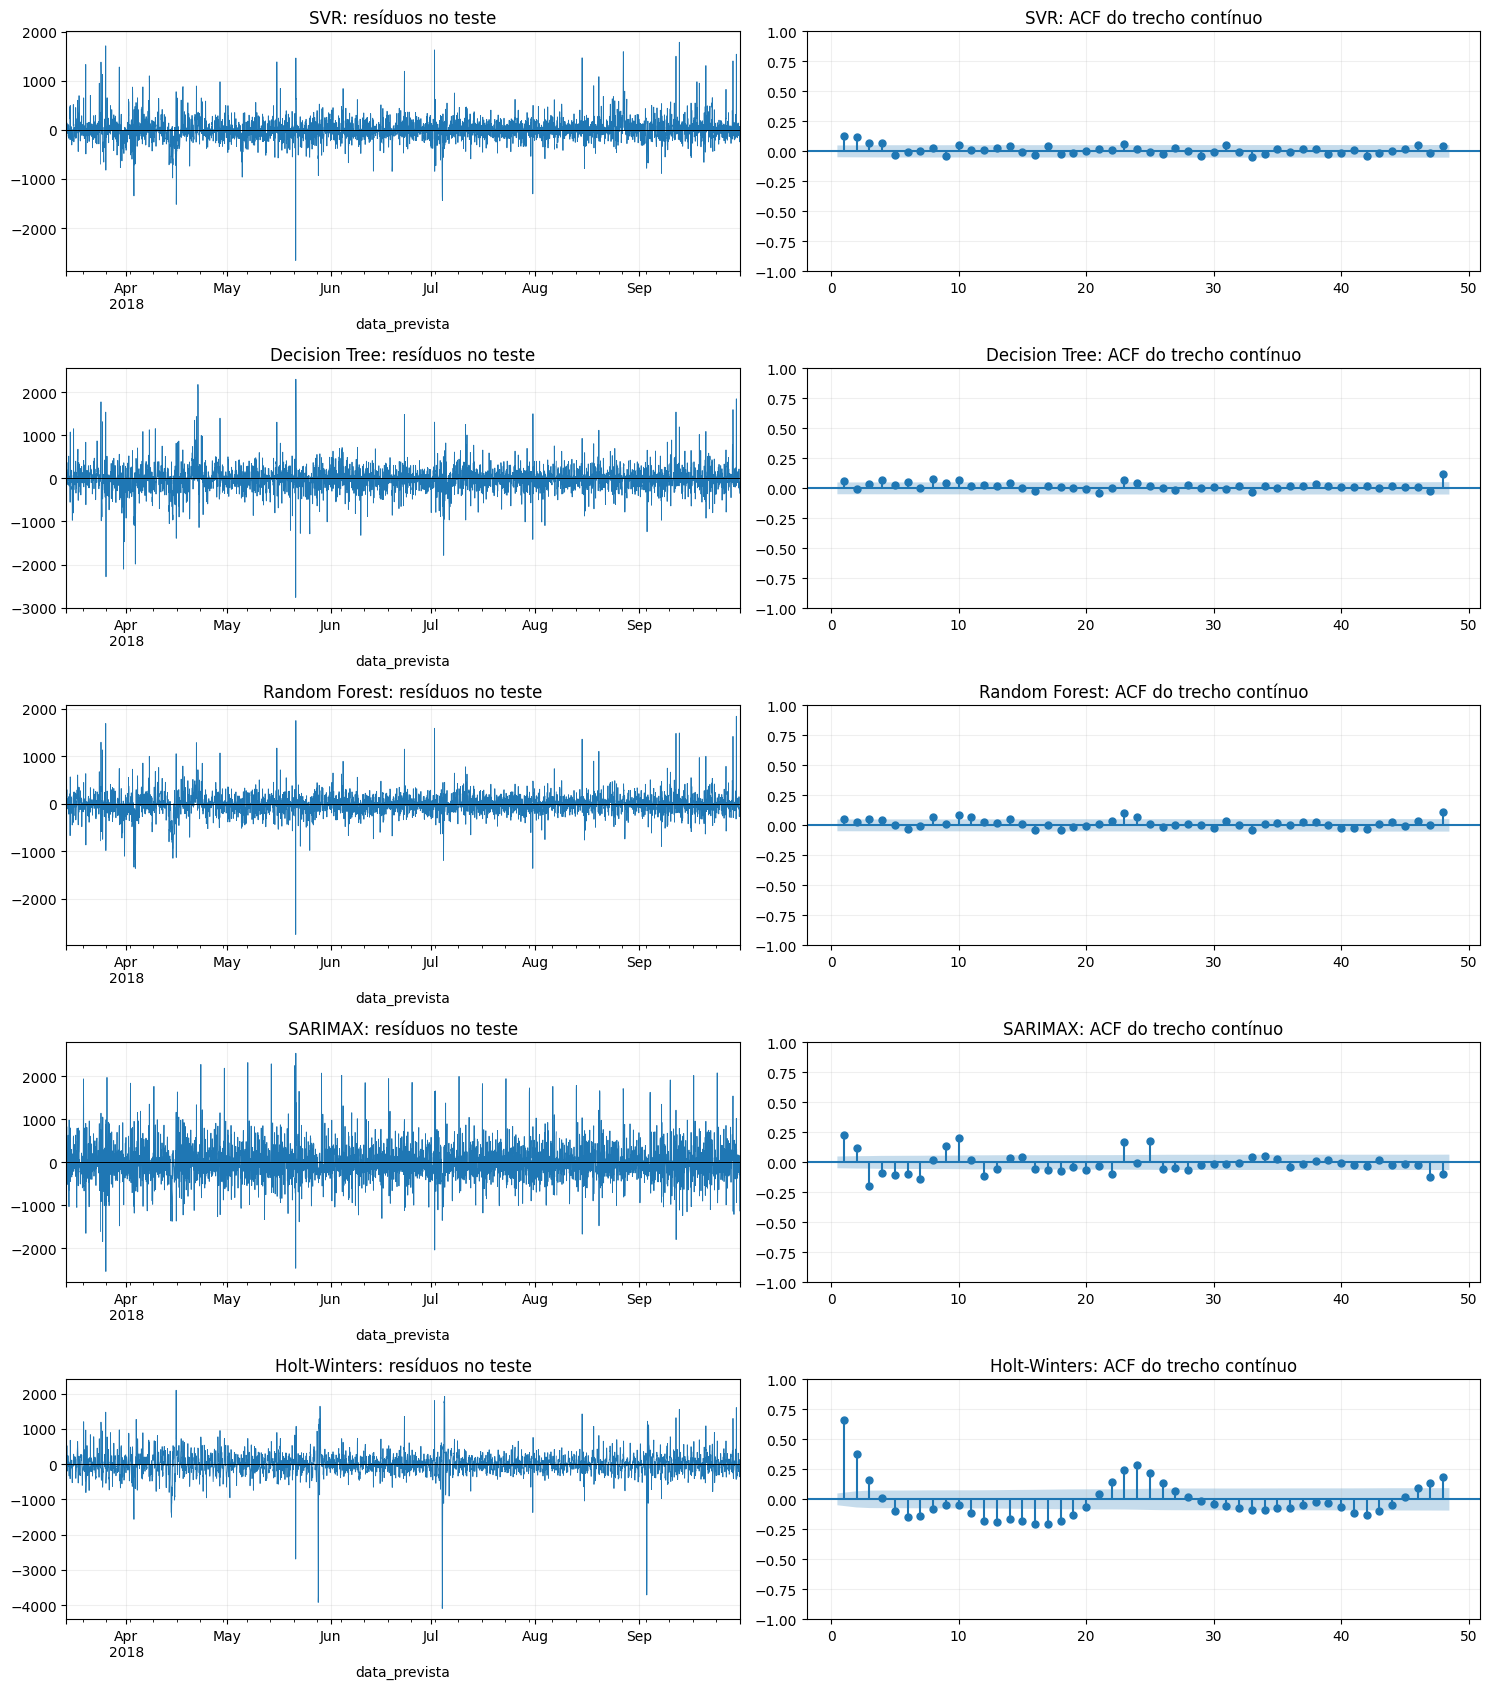

,base,modelo,lag,estatistica,p_valor,n_trecho,inicio,fim
0,base_02,SVR,24,91.857122,7.087590e-10,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
1,base_02,SVR,48,120.977828,3.142627e-08,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
2,base_02,SVR,168,277.745758,2.062013e-07,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
3,base_02,Decision Tree,24,63.600977,1.947896e-05,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
4,base_02,Decision Tree,48,99.387322,1.898279e-05,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
5,base_02,Decision Tree,168,250.407922,3.849718e-05,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
6,base_02,Random Forest,24,79.524304,7.242921e-08,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
7,base_02,Random Forest,48,115.060028,1.968740e-07,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
8,base_02,Random Forest,168,240.781906,1.967852e-04,1588,2018-06-02 03:00:00,2018-08-07 06:00:00
9,base_02,SARIMAX,24,460.534467,2.516338e-82,1588,2018-06-02 03:00:00,2018-08-07 06:00:00


Diagnóstico em 1,588 horas contínuas (33.0% das horas observadas no teste).


In [19]:
observed_mask = y.loc[wide.index].notna()
runs = observed_mask.ne(observed_mask.shift()).cumsum()
longest = observed_mask[observed_mask].groupby(runs[observed_mask]).size().idxmax()
residual_dates = observed_mask.index[(runs==longest)&observed_mask]
assert len(residual_dates)>48
assert residual_dates.to_series().diff().dropna().eq(pd.Timedelta(hours=1)).all()
lb_rows = []
fig,axes = plt.subplots(len(MODEL_NAMES),2,figsize=(15,17))
for i,name in enumerate(MODEL_NAMES):
    res = y.loc[wide.index]-wide[name]
    res.plot(ax=axes[i,0],lw=.6,title=f'{name}: resíduos no teste')
    axes[i,0].axhline(0,color='black',lw=.7)
    segment = res.loc[residual_dates]
    lags = [lag for lag in [24,48,168] if lag < len(segment)//2]
    plot_acf(segment, lags=min(48,len(segment)//2-1), zero=False, ax=axes[i,1],title=f'{name}: ACF do trecho contínuo')
    lb = acorr_ljungbox(segment,lags=lags,return_df=True,model_df=0)
    for lag,row in lb.iterrows():
        lb_rows.append({'base':BASE_ID,'modelo':name,'lag':lag,'estatistica':row.lb_stat,
            'p_valor':row.lb_pvalue,'n_trecho':len(segment),'inicio':residual_dates[0],'fim':residual_dates[-1]})
savefig('06_residuos_acf')
ljung_box = pd.DataFrame(lb_rows)
display(ljung_box)
ljung_box.to_csv(RESULTS/'residuals/base_02_ljung_box.csv',index=False)
predictions[['base','modelo','data_prevista','valor_real','valor_previsto','residuo']].to_csv(
    RESULTS/'residuals/base_02_residuals.csv',index=False)

residual_coverage = len(residual_dates) / int(observed_mask.sum())
print(f'Diagnóstico em {len(residual_dates):,} horas contínuas '
      f'({residual_coverage:.1%} das horas observadas no teste).')

## 15. Interpretação das covariáveis e importância das features

- **Random Forest, SVR e Decision Tree:** permutation importance no último fold
  de validação, usando modelo ajustado antes desse fold e os mesmos alvos observados.
- **SARIMAX:** coeficientes das exógenas padronizadas, sinais e p-valores. O alvo
  desse ajuste é dividido por mil; as magnitudes devem ser interpretadas nessa escala.
- **Holt-Winters:** nível, tendência e ciclo sazonal, sem importância de features nativa.

Features correlacionadas podem compartilhar importância. A permutação de linhas
quebra dependência temporal, por isso os valores são diagnósticos e não efeitos causais.

Como esta célula funciona — Importância por permutação

Reajusta SVR, Decision Tree e Random Forest antes do último fold de validação. Embaralha uma feature por vez, repete três vezes e mede o aumento de MAE, mostrando as dez maiores importâncias.

Decisões: interpretar na validação evita usar o teste para esta investigação. Maior aumento de erro sugere maior dependência do modelo daquela feature; resultados pequenos ou negativos exigem cautela. Correlação entre features e permutação de linhas limitam a interpretação temporal: não são efeitos causais.

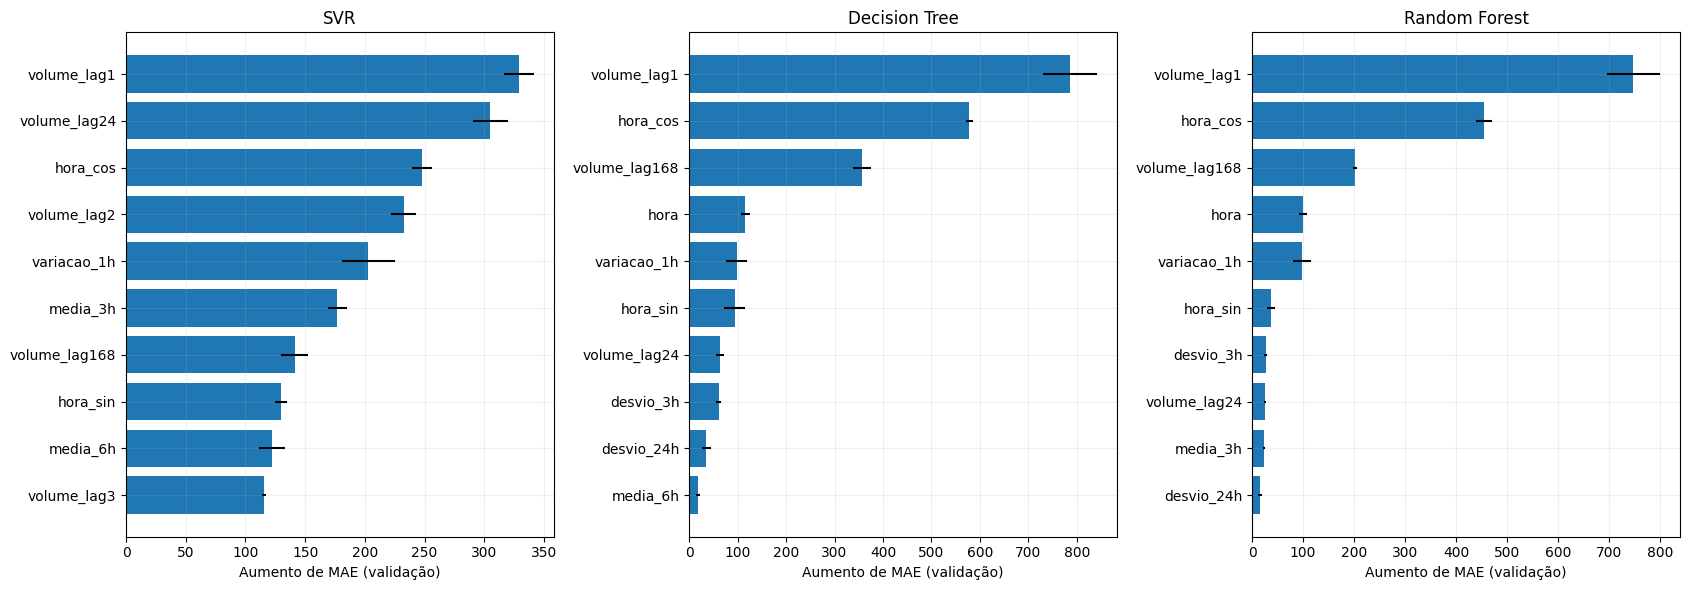

In [20]:
importance_rows = []
a,b = folds[-1]
mask = y.iloc[a:b].notna()
for name in ['SVR','Decision Tree','Random Forest']:
    _, model = forecast_block(name,selected[name],a,b,'interpretacao',True)
    imp = permutation_importance(model,X.iloc[a:b].loc[mask],y.iloc[a:b].loc[mask],
        scoring='neg_mean_absolute_error',n_repeats=3,random_state=RANDOM_STATE,n_jobs=1)
    for col,mean,std in zip(X.columns,imp.importances_mean,imp.importances_std):
        importance_rows.append({'base':BASE_ID,'modelo':name,'feature':col,
            'metodo':'permutation_validacao','aumento_mae':mean,'desvio':std})
importance = pd.DataFrame(importance_rows)
importance.to_csv(RESULTS/'feature_importance/base_02_feature_importance.csv',index=False)
fig,axes = plt.subplots(1,3,figsize=(17,6))
for ax,name in zip(axes,['SVR','Decision Tree','Random Forest']):
    top = importance[importance.modelo.eq(name)].nlargest(10,'aumento_mae').sort_values('aumento_mae')
    ax.barh(top.feature,top.aumento_mae,xerr=top.desvio)
    ax.set_title(name); ax.set_xlabel('Aumento de MAE (validação)')
savefig('07_importancia')

Como esta célula funciona — Interpretação do SARIMAX e Holt-Winters

Extrai coeficientes e p-valores das exógenas do SARIMAX e apresenta nível, tendência e último ciclo sazonal do Holt-Winters, usando ajustes anteriores ao último fold.

Decisões: no SARIMAX, as entradas são padronizadas e o alvo está dividido por mil, então os coeficientes não estão diretamente em veículos por unidade original da variável. No Holt-Winters, os componentes exibidos são reconvertidos para veículos/h. Nenhum dos dois é interpretado com a importância nativa de uma árvore.

,coeficiente,p_valor
hora_sin,-0.489769,2.752616e-39
hora_cos,-1.507140,0.000000e+00
semana_sin,0.138832,1.521465e-09
semana_cos,-0.241756,5.942722e-29
fim_de_semana,-0.086264,5.967741e-19
temp_lag1,0.024576,4.009075e-01
rain_1h_lag1,-0.002487,3.380666e-01
snow_1h_lag1,-0.001983,8.312516e-01
clouds_all_lag1,0.002868,4.820765e-01


,nivel_final_veiculos,tendencia_final,periodo_sazonal,alpha,gamma
0,3308.940605,0,168,0.2,0.1


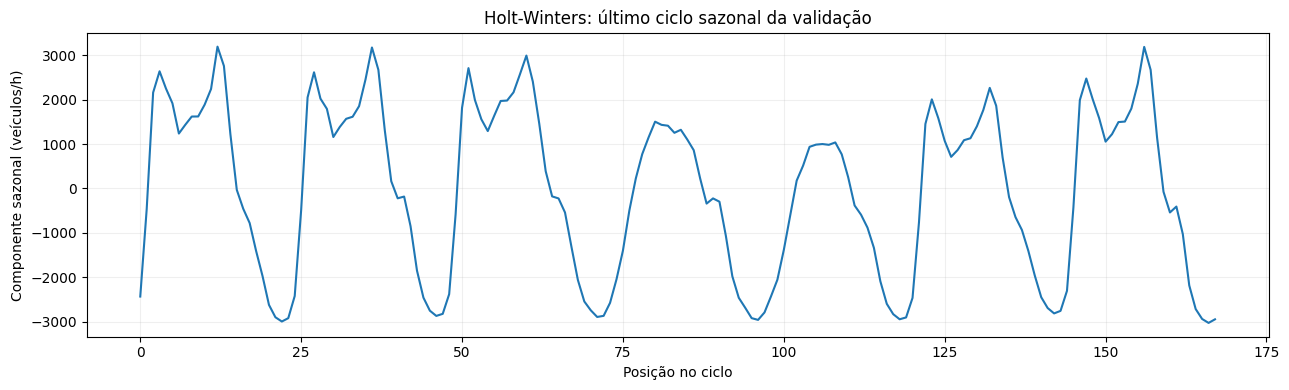

In [21]:
_, sar_art = forecast_block('SARIMAX',selected['SARIMAX'],a,b,'interpretacao',True)
sar = sar_art[0]
coefficients = pd.DataFrame({'coeficiente':sar.params,'p_valor':sar.pvalues}).loc[EXOG_COLS]
display(coefficients)
coefficients.to_csv(RESULTS/'feature_importance/base_02_sarimax_coefficients.csv',index_label='feature')

_, hw = forecast_block('Holt-Winters',selected['Holt-Winters'],a,b,'interpretacao',True)
display(pd.DataFrame([{'nivel_final_veiculos':float(hw.level.iloc[-1])*1000,
    'tendencia_final':float(hw.trend.iloc[-1])*1000 if hw.model.has_trend else 0,
    'periodo_sazonal':hw.model.seasonal_periods,'alpha':hw.params['smoothing_level'],
    'gamma':hw.params['smoothing_seasonal']}]))
pd.Series(np.asarray(hw.season[-hw.model.seasonal_periods:])*1000).plot(
    title='Holt-Winters: último ciclo sazonal da validação',ylabel='Componente sazonal (veículos/h)',xlabel='Posição no ciclo')
savefig('08_hw_sazonalidade')

## 16. Exportação, interpretação final e validação dos artefatos

Salvar o contrato comum de previsões, métricas, resíduos e importância, além do
manifesto e logs de ajuste. A base processada conserva a grade e os alvos ausentes.
O texto de análise é construído a partir desta execução e informa o ranking oficial,
o experimento extra, o benchmark e as limitações do diagnóstico.

Como esta célula funciona — Construção da análise escrita

Gera um texto com vencedor oficial, diferença para o segundo colocado, erros de cada modelo, custo, desempenho mensal, horários difíceis, resíduos, features e benchmark. A árvore individual aparece separadamente.

Decisões: o texto utiliza valores calculados nesta execução, sem definir um vencedor antecipadamente. Diferença entre validação e teste não comprova sobreajuste sozinha. Também são relatadas limitações da grade pequena, da validação curta e da cobertura do diagnóstico.

In [22]:
best, runner = official_metrics.iloc[0], official_metrics.iloc[1]
relative = 100*(runner.mae-best.mae)/runner.mae
fastest = metrics.loc[metrics.tempo_teste_s.idxmin()]
lines = ['# Análise da Base 02', '',
    f'## Resultado principal', '',
    f'{best.modelo} obteve o menor MAE: {best.mae:.2f} veículos/h. '
    f'O segundo foi {runner.modelo}, com {runner.mae:.2f}. A redução relativa foi {relative:.1f}%. '
    f'A comparação usa {int(best.n_avaliadas)} horas com alvo observado entre {TEST_START} e {df.index[-1]}.', '',
    '## Leitura por modelo', '']
for row in metrics.itertuples():
    direction = 'subestimação média' if row.vies>0 else 'superestimação média'
    lines.append(f'- {row.modelo}: MAE {row.mae:.2f}, RMSE {row.rmse:.2f}, viés {row.vies:.2f} ({direction}), '
                 f'tempo de teste {row.tempo_teste_s:.1f} s. O MAE na validação foi {row.mae_validacao:.2f}.')
lines += ['', 'A diferença entre RMSE e MAE indica quanto erros grandes pesam no resultado. '
    'A diferença entre validação e teste também depende da época do ano e da dificuldade dos períodos; '
    'ela sozinha não comprova sobreajuste.', '', '## Estabilidade e custo', '',
    f'O menor tempo foi de {fastest.modelo}: {fastest.tempo_teste_s:.1f} s. '
    'Os tempos dependem da máquina e incluem os reajustes semanais; a busca não está incluída.']
monthly_wins = monthly[OFFICIAL_MODELS].idxmin(axis=1).value_counts()
lines.append('Vitórias por mês do teste: '+', '.join(f'{name}: {n}' for name,n in monthly_wins.items())+'. Meses extremos podem ser parciais.')
worst_hour = hourly[best.modelo].idxmax()
lines.append(f'Para o vencedor, a hora de maior MAE foi {worst_hour}h ({hourly.loc[worst_hour,best.modelo]:.2f} veículos/h).')
lines += ['', '## Resíduos', '',
    f'ACF e Ljung-Box usam {len(residual_dates)} horas contínuas, de {residual_dates[0]} até {residual_dates[-1]}.']
for name in MODEL_NAMES:
    rows = ljung_box[ljung_box.modelo.eq(name)]
    rejected = rows.loc[rows.p_valor.lt(.05),'lag'].astype(str).tolist()
    lines.append(f'- {name}: '+('evidência de autocorrelação nas defasagens '+', '.join(rejected)+' horas.' if rejected else
                              'não houve rejeição a 5% nas defasagens examinadas; isso não prova independência.'))
lines += ['', '## O que os modelos aproveitaram', '']
for name in ['SVR','Decision Tree','Random Forest']:
    top = importance[importance.modelo.eq(name)].nlargest(3,'aumento_mae')
    lines.append(f'- {name}: maiores aumentos de MAE na permutação: '+', '.join(
        f'{r.feature} ({r.aumento_mae:.1f})' for r in top.itertuples())+'.')

extra_result = metrics.loc[metrics.modelo.eq('Decision Tree')].iloc[0]
lines += ['', '## Experimento adicional', '',
          f'Decision Tree: MAE {extra_result.mae:.2f} veículos/h. Está fora do ranking oficial.',
          '', '## Limitações e causalidade', '',
          'A análise está organizada em 16 etapas para previsão horária de tráfego. '
          'O recorte é cronológico 80/20, com janela expansiva desde a primeira hora e reajuste semanal. '
          'Clima entra defasado; o alvo da hora prevista não entra nas features. '
          'Imputação e escala são aprendidas apenas no treino de cada janela.',
          'A busca considera uma grade pequena e somente duas semanas de validação. '
          'O melhor candidato não é um ótimo global, e pode não representar outras estações do ano.',
          f'ACF/Ljung-Box cobrem {residual_coverage:.1%} das horas observadas no teste; '
          'o trecho contínuo não representa automaticamente todo o período.',
          'As horas sem alvo real recebem previsão, mas não participam das métricas. '
          'Valores meteorológicos extremos requerem investigação da fonte; IQR não justifica remoção automática.',
          '', '## Benchmark semanal', '', baseline_comparison.round(2).to_string(index=False)]
analysis_text = '\n'.join(lines)
(RESULTS / 'analysis/base_02_analise.md').write_text(analysis_text, encoding='utf-8')
display(Markdown(analysis_text))

# Análise da Base 02

## Resultado principal

Random Forest obteve o menor MAE: 134.74 veículos/h. O segundo foi SVR, com 143.51. A redução relativa foi 6.1%. A comparação usa 4805 horas com alvo observado entre 2018-03-14 04:00:00 e 2018-09-30 23:00:00.

## Leitura por modelo

- Random Forest: MAE 134.74, RMSE 214.03, viés -9.67 (superestimação média), tempo de teste 1766.9 s. O MAE na validação foi 177.15.
- SVR: MAE 143.51, RMSE 223.66, viés -0.65 (superestimação média), tempo de teste 1838.9 s. O MAE na validação foi 160.53.
- Decision Tree: MAE 173.15, RMSE 275.41, viés -8.60 (superestimação média), tempo de teste 26.8 s. O MAE na validação foi 228.05.
- Holt-Winters: MAE 199.14, RMSE 317.28, viés -2.33 (superestimação média), tempo de teste 1.3 s. O MAE na validação foi 225.89.
- SARIMAX: MAE 290.41, RMSE 418.08, viés 1.48 (subestimação média), tempo de teste 3615.7 s. O MAE na validação foi 339.30.

A diferença entre RMSE e MAE indica quanto erros grandes pesam no resultado. A diferença entre validação e teste também depende da época do ano e da dificuldade dos períodos; ela sozinha não comprova sobreajuste.

## Estabilidade e custo

O menor tempo foi de Holt-Winters: 1.3 s. Os tempos dependem da máquina e incluem os reajustes semanais; a busca não está incluída.
Vitórias por mês do teste: Random Forest: 6, SVR: 1. Meses extremos podem ser parciais.
Para o vencedor, a hora de maior MAE foi 23h (227.58 veículos/h).

## Resíduos

ACF e Ljung-Box usam 1588 horas contínuas, de 2018-06-02 03:00:00 até 2018-08-07 06:00:00.
- SVR: evidência de autocorrelação nas defasagens 24, 48, 168 horas.
- Decision Tree: evidência de autocorrelação nas defasagens 24, 48, 168 horas.
- Random Forest: evidência de autocorrelação nas defasagens 24, 48, 168 horas.
- SARIMAX: evidência de autocorrelação nas defasagens 24, 48, 168 horas.
- Holt-Winters: evidência de autocorrelação nas defasagens 24, 48, 168 horas.

## O que os modelos aproveitaram

- SVR: maiores aumentos de MAE na permutação: volume_lag1 (329.1), volume_lag24 (305.2), hora_cos (248.1).
- Decision Tree: maiores aumentos de MAE na permutação: volume_lag1 (785.5), hora_cos (578.2), volume_lag168 (356.9).
- Random Forest: maiores aumentos de MAE na permutação: volume_lag1 (747.4), hora_cos (454.5), volume_lag168 (201.5).

## Experimento adicional

Decision Tree: MAE 173.15 veículos/h. Está fora do ranking oficial.

## Limitações e causalidade

A análise está organizada em 16 etapas para previsão horária de tráfego. O recorte é cronológico 80/20, com janela expansiva desde a primeira hora e reajuste semanal. Clima entra defasado; o alvo da hora prevista não entra nas features. Imputação e escala são aprendidas apenas no treino de cada janela.
A busca considera uma grade pequena e somente duas semanas de validação. O melhor candidato não é um ótimo global, e pode não representar outras estações do ano.
ACF/Ljung-Box cobrem 33.0% das horas observadas no teste; o trecho contínuo não representa automaticamente todo o período.
As horas sem alvo real recebem previsão, mas não participam das métricas. Valores meteorológicos extremos requerem investigação da fonte; IQR não justifica remoção automática.

## Benchmark semanal

                 modelo  mae_mesmas_datas    n
          Random Forest            134.86 4788
                    SVR            143.47 4788
          Decision Tree            172.92 4788
           Holt-Winters            199.41 4788
                SARIMAX            290.49 4788
Sazonal ingênuo (168 h)            293.65 4788

Como esta célula funciona — Exportação e rastreabilidade

Salva a base com features em Parquet e exporta previsões, métricas, logs e análises auxiliares. O manifesto registra configuração, parâmetros, versões, SHA256 da entrada e protocolo de janela expansiva.

Decisões: manter previsões para todas as horas, mas avaliar apenas alvos observados, preserva a grade sem inventar medições. As verificações finais exigem cobertura comum, métricas finitas e treino terminando antes do bloco previsto. Elas conferem consistência dos artefatos, mas não garantem que o modelo seja o melhor possível.

In [23]:
(PROJECT_ROOT / 'data/processed').mkdir(parents=True, exist_ok=True)
processed.to_parquet(PROJECT_ROOT / 'data/processed/base_02.parquet')
predictions.to_csv(RESULTS / 'predictions/base_02_predictions.csv', index=False)
metrics.to_csv(RESULTS / 'metrics/base_02_metrics.csv', index=False)

logs = pd.DataFrame(fit_logs)
logs.to_csv(RESULTS/'tuning/base_02_fit_log.csv',index=False)
stl_summary.to_csv(RESULTS/'metrics/base_02_sazonalidade.csv',index=False)
monthly.to_csv(RESULTS/'metrics/base_02_mae_mensal.csv')
hourly.to_csv(RESULTS/'metrics/base_02_mae_horario.csv')
baseline_comparison.to_csv(RESULTS/'metrics/base_02_baseline.csv',index=False)
manifest = {'base':BASE_ID,'random_state':RANDOM_STATE,'frequencia':FREQ,'horizonte':HORIZON,
    'treino_proporcao_grade':TRAIN_RATIO,'teste_inicio':str(TEST_START),'teste_fim':str(df.index[-1]),
    'janela_tipo':'expansiva','janela_ajuste_horas':None,'treino_inicio_posicao':TRAIN_START_POS,
    'refit_horas':REFIT_HOURS,'validacao_folds':folds,
    'parametros':selected,'feature_cols':list(X.columns),'sarimax_exog':EXOG_COLS,
    'sha256_entrada':hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    'versoes':{'python':platform.python_version(),'pandas':pd.__version__,'sklearn':sklearn.__version__,
               'statsmodels':statsmodels.__version__},
    'modelos_oficiais':OFFICIAL_MODELS, 'modelos_extras':EXTRA_MODELS,
    'organizacao':'16 etapas para previsao horaria de trafego',
    'protocolo':'one-step, janela expansiva, reajuste semanal, estados e lags atualizados a cada hora',
    'avaliacao':'somente alvos observados nas mesmas datas dos cinco modelos'}
(RESULTS/'tuning/base_02_manifest.json').write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding='utf-8')
saved = pd.read_csv(RESULTS/'predictions/base_02_predictions.csv')
assert len(saved)==len(wide)*len(MODEL_NAMES)
assert saved.groupby('modelo').alvo_observado.sum().nunique()==1
assert np.isfinite(metrics[['mae','rmse','vies']].to_numpy()).all()
assert logs.treino_fim.lt(logs.previsao_inicio).all()
print('Concluído: cinco modelos, mesmas datas, análise e arquivos exportados.')
display(metrics[['ranking','modelo','mae','rmse','n_avaliadas']].round(2))

Concluído: cinco modelos, mesmas datas, análise e arquivos exportados.


,ranking,modelo,mae,rmse,n_avaliadas
0,1,Random Forest,134.74,214.03,4805
1,2,SVR,143.51,223.66,4805
2,3,Decision Tree,173.15,275.41,4805
3,4,Holt-Winters,199.14,317.28,4805
4,5,SARIMAX,290.41,418.08,4805
